Loaded: /nfsshare/users/manjula/svamitva_project/final_analysis_summary.csv
                                 Village  Total     Size_MB  RCC_Roof  \
0  ANAITPURA_FATEHGARH SAHIB_32705_ORTHO  34546   58.781250     32429   
1              BADRA_BARNALA_40044_ORTHO  64102  111.492188     61958   
2             BAGAI JHARIYA_434310_ORTHO  15223   27.050781     14945   
3                 BASANTPUR_434297_ORTHO  14018   35.656250     13512   
4    BUTTAR SIVIYA _AMRITSAR_37810_ORTHO  68892  113.378906     57643   

   Tiled_Roof  Tin_Roof  Thatched_Roof  Road  Waterbody  Transformer  Tank  \
0           0         0           2025     1          1           84     6   
1           0         0           1990     0          0          141    13   
2           0         3            241     0          4           30     0   
3           0        13            457     0          3           32     1   
4           0         5          11010     0          5          220     9   

   Well  
0     

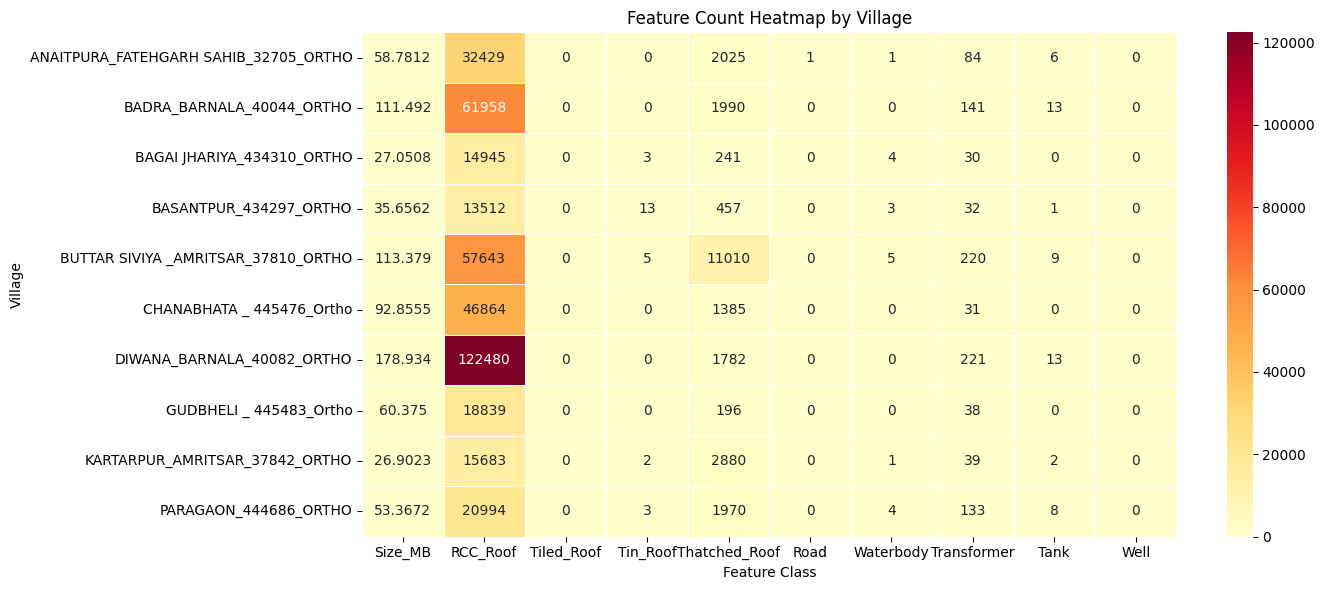


[2] Creating Donut Chart...


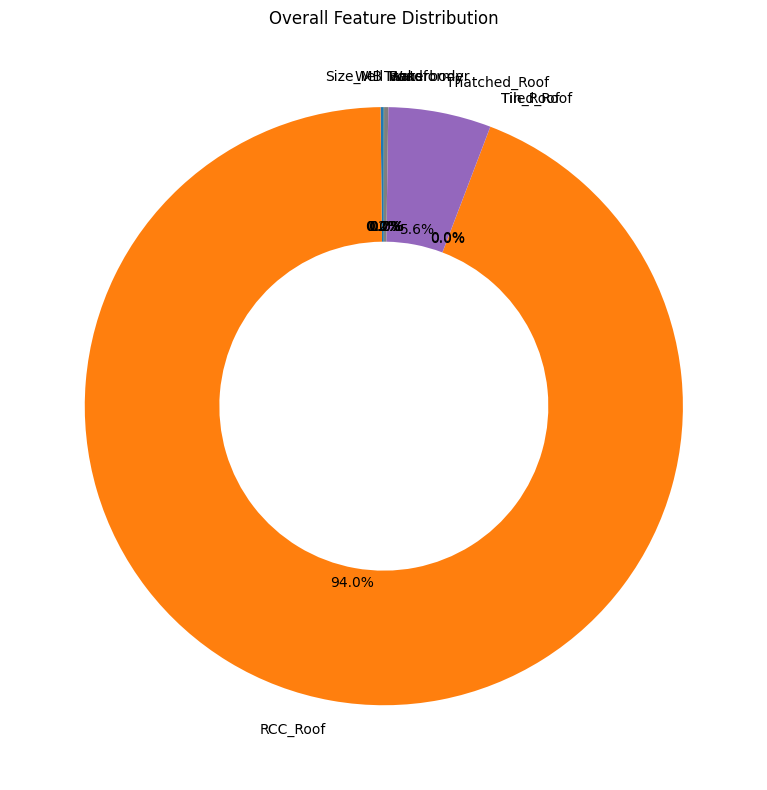


Saved:
feature_heatmap.png
feature_donut_chart.png


In [21]:
# ============================================================
# RUN THIS AS SEPARATE NOTEBOOK CELL (Independent Version)
# Creates 2 extra visualizations from saved CSV file
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE = "/nfsshare/users/manjula/svamitva_project"
csv_file = f"{BASE}/final_analysis_summary.csv"

if not os.path.exists(csv_file):
    print("final_analysis_summary.csv not found")
else:
    df = pd.read_csv(csv_file)

    print("Loaded:", csv_file)
    print(df.head())

    # ========================================================
    # 1. Heatmap of Feature Presence by Village
    # ========================================================
    print("\n[1] Creating Feature Heatmap...")

    cols = [c for c in df.columns if c not in ["Village", "Total"]]

    plt.figure(figsize=(14,6))
    sns.heatmap(
        df.set_index("Village")[cols],
        cmap="YlOrRd",
        annot=True,
        fmt="g",
        linewidths=0.5
    )

    plt.title("Feature Count Heatmap by Village")
    plt.xlabel("Feature Class")
    plt.ylabel("Village")
    plt.tight_layout()
    plt.savefig(f"{BASE}/feature_heatmap.png", dpi=150)
    plt.show()

    # ========================================================
    # 2. Donut Chart of Total Feature Distribution
    # ========================================================
    print("\n[2] Creating Donut Chart...")

    totals = df[cols].sum()

    fig, ax = plt.subplots(figsize=(8,8))
    ax.pie(
        totals,
        labels=totals.index,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops=dict(width=0.45)
    )

    ax.set_title("Overall Feature Distribution")
    plt.tight_layout()
    plt.savefig(f"{BASE}/feature_donut_chart.png", dpi=150)
    plt.show()

    print("\nSaved:")
    print("feature_heatmap.png")
    print("feature_donut_chart.png")

In [11]:
"""
SVAMITVA Project — Complete Pipeline
=====================================
Stage 1  Mask generation  ->  data/training/masks_raster/
Stage 2  Patch extraction ->  data/training/patches/{images,masks}/
Stage 3  Augmentation     ->  same patch dirs (minority classes)
Stage 4  Train DuSA U-Net ->  outputs/best_model.pth
Stage 5  Train R-CNN      ->  outputs/final/faster_rcnn_utilities.pth
Stage 6  Inference        ->  outputs/predictions/ + outputs/rcnn_utilities/
Stage 7  Merge+Eval+Vis   ->  outputs/final_predictions/ + charts

Usage
-----
python svamitva_pipeline.py --stage all      # full run
python svamitva_pipeline.py --stage 1        # masks only
python svamitva_pipeline.py --stage 1,2,3    # comma list
python svamitva_pipeline.py --stage 4,5      # training only
"""

# stdlib
import argparse, glob, os, random, sys, warnings
from collections import defaultdict

warnings.filterwarnings("ignore")
random.seed(42)

HPC_PROJECT = "/nfsshare/users/manjula/svamitva_project"
if os.path.isdir(HPC_PROJECT):
    sys.path.insert(0, HPC_PROJECT)

# ============================================================
# SHARED CONSTANTS
# ============================================================

CLASS_NAMES = {
    0: "Background", 1: "RCC_Roof",  2: "Tiled_Roof",  3: "Tin_Roof",
    4: "Thatched_Roof", 5: "Road",   6: "Waterbody",   7: "Transformer",
    8: "Tank",          9: "Well",
}

MODEL_SOURCES = {
    "RCC_Roof":"DuSA U-Net","Tiled_Roof":"DuSA U-Net","Tin_Roof":"DuSA U-Net",
    "Thatched_Roof":"DuSA U-Net","Road":"DuSA U-Net","Waterbody":"DuSA U-Net",
    "Transformer":"Faster R-CNN","Tank":"Faster R-CNN","Well":"DuSA U-Net",
}

FEATURE_COLORS = {
    1:{"name":"RCC_Roof",      "hex":"#E74C3C","rgb":(231, 76, 60)},
    2:{"name":"Tiled_Roof",    "hex":"#E67E22","rgb":(230,126, 34)},
    3:{"name":"Tin_Roof",      "hex":"#F1C40F","rgb":(241,196, 15)},
    4:{"name":"Thatched_Roof", "hex":"#8B4513","rgb":(139, 69, 19)},
    5:{"name":"Road",          "hex":"#95A5A6","rgb":(149,165,166)},
    6:{"name":"Waterbody",     "hex":"#3498DB","rgb":( 52,152,219)},
    7:{"name":"Transformer",   "hex":"#9B59B6","rgb":(155, 89,182)},
    8:{"name":"Tank",          "hex":"#1ABC9C","rgb":( 26,188,156)},
    9:{"name":"Well",          "hex":"#2ECC71","rgb":( 46,204,113)},
}

WORKING_VILLAGES = ["BADETUMNAR","MURDANDA","NAGUL","28996","PINDORI","TIMMOWAL"]
HPC_PROJECT = "/nfsshare/users/manjula/svamitva_project"
DATA_ROOT   = f"{HPC_PROJECT}/data"

PATHS = {
    "train_images": f"{DATA_ROOT}/training/images",
    "train_masks":  f"{DATA_ROOT}/training/masks_raster",
    "patch_images": f"{DATA_ROOT}/training/patches/images",
    "patch_masks":  f"{DATA_ROOT}/training/patches/masks",

    "test_images":  f"{DATA_ROOT}/testing/images",

    "unet_out":   f"{HPC_PROJECT}/outputs/predictions",
    "rcnn_out":   f"{HPC_PROJECT}/outputs/rcnn_utilities",
    "final_out":  f"{HPC_PROJECT}/outputs/final_predictions",

    "unet_model": f"{HPC_PROJECT}/outputs/best_model.pth",
    "rcnn_model": f"{HPC_PROJECT}/outputs/final/faster_rcnn_utilities.pth",

    "samples":    f"{HPC_PROJECT}/samples",
}


_SHP_CANDIDATES = [
    "/nfsshare/users/manjula/svamitva_project/data/training/masks",
    "/nfsshare/users/manjula/svamitva_project/data/raw/shp-file",
    "/nfsshare/users/manjula/svamitva_project/data/raw/PB_training_dataSet_shp_file",
]

def _banner(t): print("\n"+"="*70+"\n"+t+"\n"+"="*70)
def _mkdirs(*d): [os.makedirs(x, exist_ok=True) for x in d]
def _find_shp():
    for d in _SHP_CANDIDATES:
        if os.path.isdir(d): return d
    return None

# ============================================================
# STAGE 1 — MASK GENERATION
# ============================================================

def stage1_mask_generation():
    _banner("STAGE 1 — MASK GENERATION")
    import numpy as np, rasterio
    from rasterio import features as rf
    import geopandas as gpd
    from shapely.geometry import box as sbox

    shp_dir = _find_shp()
    if not shp_dir:
        print("ERROR: shapefile dir not found. Checked:", _SHP_CANDIDATES); return False

    tifs = sorted(glob.glob(os.path.join(PATHS["train_images"],"*.tif")))
    if not tifs:
        print("ERROR: no .tif in", PATHS["train_images"]); return False

    print(f"  Shapefiles : {shp_dir}")
    print(f"  Images     : {len(tifs)}")

    # load shapefiles once
    layers = {}
    for fname, cid in [
    ("Built_Up_Area_type.shp", None),
    ("Built_Up_Area_typ.shp", None),
    ("Road.shp", 5),
    ("Water_Body.shp", 6),
    ("Utility.shp", 7)
]:
        p = os.path.join(shp_dir, fname)
        if os.path.exists(p):
            layers[fname] = (gpd.read_file(p), cid)
            print(f"  loaded {fname} ({len(layers[fname][0])} rows)")
        else:
            print(f"  WARNING: {fname} not found")

    _mkdirs(PATHS["train_masks"])
    ok = 0
    for tif in tifs:
        stem = os.path.splitext(os.path.basename(tif))[0]
        out  = os.path.join(PATHS["train_masks"], f"{stem}_mask.tif")
        if os.path.exists(out):
            print(f"  {stem}: already exists"); ok+=1; continue
        try:
            with rasterio.open(tif) as src:
                H,W = src.height, src.width
                tfm = src.transform
                meta = src.meta.copy()
                bounds = sbox(*src.bounds)
            mask = np.zeros((H,W), dtype=np.uint8)
            for fname,(gdf,cid) in layers.items():
                gdf_f = gdf[gdf.intersects(bounds)]
                if gdf_f.empty: continue
                if fname=="Built_Up_Area_type.shp":
                    rm={1:1,2:2,3:3,4:4}
                    shapes=[(r.geometry,rm.get(int(r["Roof_type"]),1))
                            for _,r in gdf_f.iterrows() if r.geometry]
                else:
                    shapes=[(g,cid) for g in gdf_f.geometry if g]
                if shapes:
                    burned=rf.rasterize(shapes,out_shape=(H,W),
                                        transform=tfm,fill=0,dtype=np.uint8)
                    mask=np.maximum(mask,burned)
            meta.update(dtype=rasterio.uint8,count=1,compress="lzw",nodata=None)
            meta.pop("photometric",None)
            with rasterio.open(out,"w",**meta) as dst: dst.write(mask,1)
            print(f"  {stem}_mask.tif  fg={int(np.sum(mask>0)):,}")
            ok+=1
        except Exception as e:
            print(f"  ERROR {stem}: {e}")
    print(f"\n  Done: {ok}/{len(tifs)} masks -> {PATHS['train_masks']}/")
    return ok>0

# ============================================================
# STAGE 2 — PATCH EXTRACTION
# ============================================================

def stage2_patch_extraction():
    _banner("STAGE 2 — PATCH EXTRACTION")
    import numpy as np, rasterio
    from rasterio.windows import Window
    from PIL import Image

    PS,ST = 512,256
    _mkdirs(PATHS["patch_images"],PATHS["patch_masks"])

    all_masks = sorted(glob.glob(os.path.join(PATHS["train_masks"],"*.tif")))
    if not all_masks:
        print("ERROR: no masks in",PATHS["train_masks"],". Run Stage 1."); return False

    pairs=[]
    for mp in all_masks:
        stem = os.path.splitext(os.path.basename(mp))[0]
        img_stem = stem[:-5] if stem.endswith("_mask") else stem
        if not any(v.upper() in img_stem.upper() for v in WORKING_VILLAGES): continue
        ip = os.path.join(PATHS["train_images"], f"{img_stem}.tif")
        if not os.path.exists(ip):
            print(f"  WARNING: image not found for {os.path.basename(mp)}"); continue
        pairs.append((ip,mp,img_stem))

    if not pairs:
        print("ERROR: no village pairs found.")
        print("  Available masks:", [os.path.basename(m) for m in all_masks[:10]])
        return False

    total_new=0
    for img_path,mask_path,stem in pairs:
        exist=len(glob.glob(os.path.join(PATHS["patch_images"],f"{stem}_*.png")))
        new=skip=0
        try:
            with rasterio.open(img_path) as isrc, rasterio.open(mask_path) as msrc:
                H,W,nb = isrc.height, isrc.width, isrc.count
                print(f"  [{stem}] {W}x{H}  existing={exist}")
                for y in range(0,H-PS+1,ST):
                    for x in range(0,W-PS+1,ST):
                        pn = f"{stem}_{y}_{x}.png"
                        pi = os.path.join(PATHS["patch_images"],pn)
                        pm = os.path.join(PATHS["patch_masks"],pn)
                        if os.path.exists(pi): skip+=1; continue
                        win=Window(x,y,PS,PS)
                        ip=isrc.read(window=win); mp=msrc.read(1,window=win)
                        if mp.max()==0: skip+=1; continue
                        ip=ip[:3] if nb>=3 else np.repeat(ip,3,axis=0)
                        ip=np.transpose(ip,(1,2,0)).astype(np.float32)
                        lo,hi=ip.min(),ip.max()
                        ip=((ip-lo)/(hi-lo+1e-8)*255).astype(np.uint8)
                        Image.fromarray(ip).save(pi)
                        Image.fromarray(mp).save(pm)
                        new+=1
        except Exception as e:
            print(f"  ERROR {stem}: {e}"); continue
        print(f"    new={new} skipped={skip}")
        total_new+=new

    total=len(glob.glob(os.path.join(PATHS["patch_images"],"*.png")))
    print(f"\n  New={total_new}  Total on disk={total:,}")
    return total>0

# ============================================================
# STAGE 3 — AUGMENTATION
# ============================================================

def stage3_augmentation():
    _banner("STAGE 3 — MINORITY-CLASS AUGMENTATION")
    import numpy as np, cv2

    TARGETS={8:("Tank",5), 9:("Well",65)}
    idir=PATHS["patch_images"]; mdir=PATHS["patch_masks"]

    for cval,(label,n) in TARGETS.items():
        srcs=[]
        for f in sorted(os.listdir(idir)):
            if f.startswith("aug_"): continue
            mp=os.path.join(mdir,f)
            if not os.path.exists(mp): continue
            m=cv2.imread(mp,cv2.IMREAD_GRAYSCALE)
            if m is not None and cval in np.unique(m): srcs.append(f)
        print(f"\n  {label}: {len(srcs)} sources x {n} = {len(srcs)*n} augments")
        if not srcs: print("  WARNING: no source patches"); continue
        cnt=0
        for f in srcs:
            img =cv2.imread(os.path.join(idir,f))
            mask=cv2.imread(os.path.join(mdir,f),cv2.IMREAD_GRAYSCALE)
            if img is None or mask is None: continue
            for _ in range(n):
                fl=random.choice([-2,-1,0,1])
                ai=cv2.flip(img,fl)  if fl!=-2 else img.copy()
                am=cv2.flip(mask,fl) if fl!=-2 else mask.copy()
                ai=cv2.convertScaleAbs(ai,alpha=random.uniform(0.7,1.4),
                                          beta=random.uniform(-40,40))
                nf=f"aug_{label.lower()}_{cnt}_{f}"
                cv2.imwrite(os.path.join(idir,nf),ai)
                cv2.imwrite(os.path.join(mdir,nf),am)
                cnt+=1
        print(f"  Generated {cnt}")

    total=len(glob.glob(os.path.join(idir,"*.png")))
    print(f"\n  Total patches after augmentation: {total:,}")
    return True

# ============================================================
# STAGE 4 — TRAIN DuSA U-Net
# ============================================================

def stage4_train_unet():
    _banner("STAGE 4 — TRAIN DuSA U-Net")
    import numpy as np, torch, torch.nn as nn, torch.optim as optim
    from torch.utils.data import Dataset, DataLoader, Subset
    from PIL import Image
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    from models.dusa_unet import DuSA_UNet

    os.environ["CUDA_VISIBLE_DEVICES"]="5"
    os.environ["PYTORCH_CUDA_ALLOC_CONF"]="expandable_segments:True"
    torch.manual_seed(42); np.random.seed(42)

    AUG_TR=A.Compose([
        A.HorizontalFlip(p=0.5),A.VerticalFlip(p=0.5),A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(p=0.3),A.RandomGamma(p=0.3),A.GaussNoise(p=0.2),
        A.ElasticTransform(p=0.2,alpha=1,sigma=50),A.CLAHE(p=0.3),
        A.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]),ToTensorV2()])
    AUG_VA=A.Compose([
        A.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]),ToTensorV2()])

    class PDS(Dataset):
        def __init__(self,aug):
            self.imgs =sorted(glob.glob(os.path.join(PATHS["patch_images"],"*.png")))
            self.masks=sorted(glob.glob(os.path.join(PATHS["patch_masks"], "*.png")))
            self.aug=aug
        def __len__(self): return len(self.imgs)
        def __getitem__(self,i):
            img =np.array(Image.open(self.imgs[i]).convert("RGB"))
            mask=np.clip(np.array(Image.open(self.masks[i])),0,9)
            out =self.aug(image=img,mask=mask)
            return out["image"],out["mask"].long()

    n=len(glob.glob(os.path.join(PATHS["patch_images"],"*.png")))
    if n==0:
        print("ERROR: no patches. Run Stages 1-3 first."); return False

    idx=list(range(n)); random.shuffle(idx)
    vn=int(0.2*n); tr_i=idx[vn:]; va_i=idx[:vn]
    tr_ds=Subset(PDS(AUG_TR),tr_i); va_ds=Subset(PDS(AUG_VA),va_i)
    tr_ld=DataLoader(tr_ds,batch_size=16,shuffle=True, num_workers=8,pin_memory=True,persistent_workers=True)
    va_ld=DataLoader(va_ds,batch_size=16,shuffle=False,num_workers=8,pin_memory=True,persistent_workers=True)
    print(f"  Train={len(tr_ds):,}  Val={len(va_ds):,}")

    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model=DuSA_UNet(n_classes=10).to(device)
    print(f"  Device={device}  Params={sum(p.numel() for p in model.parameters())/1e6:.2f}M")

    start,best=0,0.0
    for ck in [PATHS["unet_model"],"outputs/best_model_resumed.pth"]:
        if os.path.exists(ck):
            model.load_state_dict(torch.load(ck,map_location=device))
            start=12; best=91.75
            print(f"  Resumed: {ck}"); break

    class LSCe(nn.Module):
        def __init__(self,s=0.1): super().__init__(); self.s=s
        def forward(self,p,t):
            n=p.size(1); lp=nn.functional.log_softmax(p,dim=1)
            with torch.no_grad():
                td=torch.full_like(p,self.s/(n-1)); td.scatter_(1,t.unsqueeze(1),1-self.s)
            return (-td*lp).sum(1).mean()

    crit=LSCe(0.1)
    opt =optim.AdamW(model.parameters(),lr=1e-4,weight_decay=1e-4)
    sch =optim.lr_scheduler.OneCycleLR(opt,max_lr=1e-3,total_steps=len(tr_ld)*50,
         pct_start=0.3,anneal_strategy="cos",
         last_epoch=(start*len(tr_ld)-1) if start else -1)
    scaler=torch.cuda.amp.GradScaler()
    _mkdirs("outputs")
    print(f"  Starting epoch {start+1}/50  best={best:.2f}%\n")

    for epoch in range(start,50):
        model.train(); tl=0.0
        for imgs,masks in tr_ld:
            imgs,masks=imgs.to(device),masks.to(device)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(): loss=crit(model(imgs),masks)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            sch.step(); tl+=loss.item()
        tl/=len(tr_ld)
        model.eval(); correct=total=0; vl=0.0
        with torch.no_grad():
            for imgs,masks in va_ld:
                imgs,masks=imgs.to(device),masks.to(device)
                with torch.cuda.amp.autocast(): out=model(imgs); loss=crit(out,masks)
                vl+=loss.item(); pred=torch.argmax(out,1)
                correct+=(pred==masks).sum().item(); total+=masks.numel()
        vl/=len(va_ld); acc=correct/total*100
        flag=""
        if acc>best:
            best=acc; torch.save(model.state_dict(),PATHS["unet_model"]); flag="  <- best"
        print(f"  Ep {epoch+1:3d}/50  tr={tl:.4f}  val={vl:.4f}  acc={acc:.2f}%{flag}")
        torch.cuda.empty_cache()

    print(f"\n  Best accuracy: {best:.2f}%  saved -> {PATHS['unet_model']}")
    return True

# ============================================================
# STAGE 5 — TRAIN Faster R-CNN
# ============================================================

def stage5_train_rcnn():
    _banner("STAGE 5 — TRAIN Faster R-CNN (Utilities)")
    import math, numpy as np, torch, cv2
    from torch.utils.data import Dataset, DataLoader, Subset
    from torchvision import transforms as T
    from torchvision.models.detection import fasterrcnn_resnet50_fpn
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    from torchvision.models.detection.anchor_utils import AnchorGenerator
    from tqdm import tqdm

    os.environ["CUDA_VISIBLE_DEVICES"]="6"
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"  Device: {device}")

    KERNEL=np.ones((17,17),np.uint8)
    M2C={7:1,8:2,9:3}

    class UDS(Dataset):
        def __init__(self):
            self.imgs=sorted(os.listdir(PATHS["patch_images"]))
        def __len__(self): return len(self.imgs)
        def __getitem__(self,idx):
            f=self.imgs[idx]
            img=cv2.cvtColor(cv2.imread(os.path.join(PATHS["patch_images"],f)),
                              cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
            mask=cv2.imread(os.path.join(PATHS["patch_masks"],f),cv2.IMREAD_GRAYSCALE)
            boxes,labels=[],[]
            for mv,ci in M2C.items():
                bm=cv2.dilate((mask==mv).astype(np.uint8),KERNEL,iterations=1)
                try: nl,_,stats,_=cv2.connectedComponentsWithStats(bm,connectivity=8)
                except cv2.error: continue
                for i in range(1,nl):
                    x,y=stats[i,cv2.CC_STAT_LEFT],stats[i,cv2.CC_STAT_TOP]
                    w,h=stats[i,cv2.CC_STAT_WIDTH],stats[i,cv2.CC_STAT_HEIGHT]
                    if w>=2 and h>=2:
                        boxes.append([float(x),float(y),float(x+w),float(y+h)]); labels.append(ci)
            boxes=torch.as_tensor(boxes,dtype=torch.float32)
            labels=torch.as_tensor(labels,dtype=torch.int64); iid=torch.tensor([idx])
            if len(boxes):
                tgt={"boxes":boxes,"labels":labels,"image_id":iid,
                     "area":(boxes[:,3]-boxes[:,1])*(boxes[:,2]-boxes[:,0]),
                     "iscrowd":torch.zeros(len(boxes),dtype=torch.int64)}
            else:
                tgt={"boxes":torch.zeros((0,4),dtype=torch.float32),
                     "labels":torch.zeros((0,),dtype=torch.int64),"image_id":iid,
                     "area":torch.zeros((0,),dtype=torch.float32),
                     "iscrowd":torch.zeros((0,),dtype=torch.int64)}
            return T.ToTensor()(img),tgt

    def colfn(b): return tuple(zip(*b))

    def get_m(nc=4):
        anc=AnchorGenerator(sizes=((16,),(32,),(64,),(128,),(256,)),
                            aspect_ratios=((0.5,1.0,2.0),)*5)
        m=fasterrcnn_resnet50_fpn(weights="DEFAULT",rpn_anchor_generator=anc,box_nms_thresh=0.2)
        inf=m.roi_heads.box_predictor.cls_score.in_features
        m.roi_heads.box_predictor=FastRCNNPredictor(inf,nc); return m

    full=UDS()
    masks_list=sorted(os.listdir(PATHS["patch_masks"]))
    print("  Scanning utility patches...")
    ui,ei=[],[]
    for i,f in enumerate(tqdm(masks_list,desc="scan")):
        m=cv2.imread(os.path.join(PATHS["patch_masks"],f),cv2.IMREAD_GRAYSCALE)
        if m is None: continue
        has=False
        if np.any(np.isin(m,[7,8,9])):
            for mv in [7,8,9]:
                bm=cv2.dilate((m==mv).astype(np.uint8),KERNEL,iterations=1)
                try:
                    nl,_,stats,_=cv2.connectedComponentsWithStats(bm,connectivity=8)
                    for j in range(1,nl):
                        if stats[j,cv2.CC_STAT_WIDTH]>=2 and stats[j,cv2.CC_STAT_HEIGHT]>=2:
                            has=True; break
                except cv2.error: pass
                if has: break
        (ui if has else ei).append(i)

    ne=int(len(ui)*0.20); random.shuffle(ei); active=ui+ei[:ne]
    print(f"  Utility={len(ui)}  Hard-neg={ne}")
    sub=Subset(full,active); tn=int(0.8*len(sub))
    gen=torch.Generator().manual_seed(42)
    tr,va=torch.utils.data.random_split(sub,[tn,len(sub)-tn],generator=gen)
    tr_ld=DataLoader(tr,batch_size=2,shuffle=True, num_workers=2,collate_fn=colfn)
    va_ld=DataLoader(va,batch_size=1,shuffle=False,num_workers=2,collate_fn=colfn)
    print(f"  Train={len(tr)}  Val={len(va)}")

    model=get_m(4).to(device)
    params=[p for p in model.parameters() if p.requires_grad]
    opt=torch.optim.SGD(params,lr=5e-4,momentum=0.9,weight_decay=5e-4)
    sch=torch.optim.lr_scheduler.StepLR(opt,step_size=10,gamma=0.2)
    _mkdirs("outputs/final")

    def cdist(b1,b2):
        return math.hypot((b1[0]+b1[2])/2-(b2[0]+b2[2])/2,(b1[1]+b1[3])/2-(b2[1]+b2[3])/2)

    for epoch in range(40):
        model.train(); el=0.0
        for imgs,tgts in tr_ld:
            imgs=[i.to(device) for i in imgs]
            tgts=[{k:v.to(device) for k,v in t.items()} for t in tgts]
            ld=model(imgs,tgts); loss=sum(ld.values())
            opt.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),2.0)
            opt.step(); el+=loss.item()
        sch.step()
        model.eval(); cc={1:0,2:0,3:0}; ct={1:0,2:0,3:0}; cp={1:0,2:0,3:0}
        with torch.no_grad():
            for vi,vt in va_ld:
                vi=[i.to(device) for i in vi]
                vt=[{k:v.to(device) for k,v in t.items()} for t in vt]
                out=model(vi)
                for i,o in enumerate(out):
                    gb=vt[i]["boxes"].cpu().numpy(); gl=vt[i]["labels"].cpu().numpy()
                    pb=o["boxes"].cpu().numpy(); pl=o["labels"].cpu().numpy()
                    ps=o["scores"].cpu().numpy(); keep=ps>=0.50; pb=pb[keep]; pl=pl[keep]
                    for cls in [1,2,3]:
                        gb_c=gb[gl==cls]; pb_c=pb[pl==cls]
                        ct[cls]+=len(gb_c); cp[cls]+=len(pb_c)
                        mg=set()
                        for pb_i in pb_c:
                            bd,bi=1e9,-1
                            for gi,gb_i in enumerate(gb_c):
                                if gi in mg: continue
                                d=cdist(pb_i,gb_i)
                                if d<bd: bd,bi=d,gi
                            if bd<=10.0: cc[cls]+=1; mg.add(bi)
        tc=sum(cc.values()); tg=sum(ct.values()); tp_=sum(cp.values())
        pr=tc/tp_ if tp_ else 0; rc=tc/tg if tg else 0
        print(f"  Ep {epoch+1:2d}/40  loss={el/len(tr_ld):.4f}  prec={pr:.2%}  recall={rc:.2%}")
        torch.cuda.empty_cache()

    torch.save(model.state_dict(),PATHS["rcnn_model"])
    print(f"  Saved -> {PATHS['rcnn_model']}")
    return True

# ============================================================
# STAGE 6 — INFERENCE
# ============================================================

def stage6_inference():
    _banner("STAGE 6 — INFERENCE ON TESTING VILLAGES")
    import numpy as np, torch, rasterio
    from rasterio import features as rf
    from rasterio.windows import Window
    import geopandas as gpd
    from shapely.geometry import shape, Point
    import cv2
    from models.dusa_unet import DuSA_UNet
    from torchvision.models.detection import fasterrcnn_resnet50_fpn
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    from torchvision.models.detection.anchor_utils import AnchorGenerator

    os.environ["CUDA_VISIBLE_DEVICES"]="6"
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

    test_imgs=sorted(glob.glob(os.path.join(PATHS["test_images"],"*.tif")))
    if not test_imgs:
        print("ERROR: no test images in",PATHS["test_images"]); return False
    print(f"  Test villages: {len(test_imgs)}")

    THR={1:0.45,2:0.40,3:0.50,4:0.35,5:0.55,6:0.50,7:0.30,8:0.30,9:0.30}

    def tta(model,p):
        ps=[]
        with torch.no_grad():
            ps.append(model(p))
            for dims in ([3,],[2,],[2,3]):
                fp=torch.flip(p,dims=dims); o=model(fp)
                for d in reversed(dims): o=torch.flip(o,dims=[d])
                ps.append(o)
        return torch.stack(ps).mean(0)

    def athresh(sm):
        v=torch.zeros_like(sm)
        for c,t in THR.items(): v[c]=(sm[c]>t).float()
        return torch.argmax(v,0)

    def mclean(m,ks=3):
        k=np.ones((ks,ks),np.uint8)
        m=cv2.morphologyEx(m,cv2.MORPH_OPEN,k); m=cv2.morphologyEx(m,cv2.MORPH_CLOSE,k)
        cnts,_=cv2.findContours(m,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            if cv2.contourArea(c)<100: cv2.drawContours(m,[c],-1,0,-1)
        return m

    if not os.path.exists(PATHS["unet_model"]):
        print("ERROR: U-Net not found. Run Stage 4."); return False

    unet=DuSA_UNet(n_classes=10).to(device)
    unet.load_state_dict(torch.load(PATHS["unet_model"],map_location=device))
    unet.eval()
    _mkdirs(PATHS["unet_out"])
    FC={k:v for k,v in CLASS_NAMES.items() if k>0}
    PS,ST=512,256

    print("\n  [6a] U-Net segmentation...")
    for ip in test_imgs:
        base=os.path.splitext(os.path.basename(ip))[0]
        out=os.path.join(PATHS["unet_out"],f"{base}_features.gpkg")
        print(f"    {base}...",end=" ",flush=True)
        try:
            with rasterio.open(ip) as src:
                H,W=src.height,src.width; tfm,crs=src.transform,src.crs; nb=src.count
                pf=np.zeros((H,W),dtype=np.uint8)
                for y in range(0,H-PS+1,ST):
                    for x in range(0,W-PS+1,ST):
                        p=src.read(window=Window(x,y,PS,PS))
                        if nb==4: p=p[:3]
                        elif nb==1: p=np.repeat(p,3,axis=0)
                        pt=torch.FloatTensor(p).unsqueeze(0).to(device)
                        sm=tta(unet,pt); pr=athresh(sm[0])
                        pc=mclean(pr.cpu().numpy().astype(np.uint8))
                        pf[y:y+PS,x:x+PS]=np.maximum(pf[y:y+PS,x:x+PS],pc)
            feats=[]
            for cid,cn in FC.items():
                cm=(pf==cid).astype(np.uint8)
                if not cm.any(): continue
                for g,v in rf.shapes(cm,transform=tfm):
                    if v==1:
                        gs=shape(g); feats.append({"geometry":gs,"class_id":cid,"class_name":cn,"area":gs.area})
            if feats: gpd.GeoDataFrame(feats,crs=crs).to_file(out,driver="GPKG")
            print(f"{len(feats):,}")
        except Exception as e:
            print(f"ERROR: {e}")
        torch.cuda.empty_cache()

    if not os.path.exists(PATHS["rcnn_model"]):
        print("\n  WARNING: R-CNN model not found, skipping 6b")
    else:
        def get_r(nc=4):
            anc=AnchorGenerator(sizes=((16,),(32,),(64,),(128,),(256,)),aspect_ratios=((0.5,1.0,2.0),)*5)
            m=fasterrcnn_resnet50_fpn(weights="DEFAULT",rpn_anchor_generator=anc,box_nms_thresh=0.2)
            inf=m.roi_heads.box_predictor.cls_score.in_features
            m.roi_heads.box_predictor=FastRCNNPredictor(inf,nc); return m

        rcnn=get_r(4).to(device)
        rcnn.load_state_dict(torch.load(PATHS["rcnn_model"],map_location=device))
        rcnn.eval(); _mkdirs(PATHS["rcnn_out"])
        RC={1:"Transformer",2:"Tank",3:"Well"}; RP,RS=1024,512
        import pandas as pd; summary=[]
        print("\n  [6b] R-CNN utility detection...")
        for ip in test_imgs:
            base=os.path.splitext(os.path.basename(ip))[0]
            out=os.path.join(PATHS["rcnn_out"],f"{base}_utilities.gpkg")
            print(f"    {base}...",end=" ",flush=True); dets=[]
            try:
                with rasterio.open(ip) as src:
                    H,W=src.height,src.width; tfm,crs=src.transform,src.crs
                    for y in range(0,H-RP+1,RS):
                        for x in range(0,W-RP+1,RS):
                            p=src.read(window=Window(x,y,RP,RS))
                            if p.shape[0]<3: continue
                            rgb=np.transpose(p[:3],(1,2,0)).astype(np.float32)/255.
                            pt=torch.from_numpy(rgb).permute(2,0,1).unsqueeze(0).to(device)
                            with torch.no_grad(): pred_=rcnn([pt[0]])[0]
                            for b,l,s in zip(pred_["boxes"].cpu().numpy(),
                                             pred_["labels"].cpu().numpy(),
                                             pred_["scores"].cpu().numpy()):
                                if s>=0.3 and l in RC:
                                    cx=(b[0]+b[2])/2+x; cy=(b[1]+b[3])/2+y
                                    lon,lat=tfm*(cx,cy)
                                    dets.append({"geometry":Point(lon,lat),"class_name":RC[l],"confidence":float(s)})
                            torch.cuda.empty_cache()
                gdf=(gpd.GeoDataFrame(dets,crs=crs) if dets
                     else gpd.GeoDataFrame(columns=["geometry","class_name","confidence"],crs=crs))
                gdf.to_file(out,driver="GPKG"); print(f"{len(gdf)}")
                summary.append({"Village":base,"Utilities":len(gdf),
                    "Transformers":len(gdf[gdf.class_name=="Transformer"]) if len(gdf) else 0,
                    "Tanks":len(gdf[gdf.class_name=="Tank"]) if len(gdf) else 0,
                    "Wells":len(gdf[gdf.class_name=="Well"]) if len(gdf) else 0})
            except Exception as e:
                print(f"ERROR: {e}")
        pd.DataFrame(summary).to_csv(os.path.join(PATHS["rcnn_out"],"rcnn_summary.csv"),index=False)

    print("\n  STAGE 6 COMPLETE")
    return True

# ============================================================
# STAGE 7 — MERGE / EVALUATE / VISUALISE
# ============================================================

def stage7_merge_evaluate_visualise():
    _banner("STAGE 7 — MERGE / EVALUATE / VISUALISE")
    import numpy as np, pandas as pd
    import matplotlib.pyplot as plt, matplotlib.patches as mpatches
    import geopandas as gpd, torch
    from PIL import Image
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    from torch.utils.data import Dataset, DataLoader

    # -- 7a merge
    print("\n[7a] Merging GeoPackages...")
    _mkdirs(PATHS["final_out"])
    ug=sorted(glob.glob(os.path.join(PATHS["unet_out"],"*_features.gpkg")))
    rm={os.path.basename(f).replace("_utilities.gpkg",""):f
        for f in glob.glob(os.path.join(PATHS["rcnn_out"],"*_utilities.gpkg"))}
    vstats=[]; tbc={v:0 for k,v in CLASS_NAMES.items() if k>0}
    for uf in ug:
        v=os.path.basename(uf).replace("_features.gpkg","")
        ud=gpd.read_file(uf)
        if v in rm:
            rd=gpd.read_file(rm[v])
            if ud.crs!=rd.crs: rd=rd.to_crs(ud.crs)
            comb=pd.concat([ud,rd],ignore_index=True)
            print(f"  {v}: {len(ud)}+{len(rd)}->{len(comb)}")
        else:
            comb=ud; print(f"  {v}: unet only ({len(ud)})")
        comb.to_file(os.path.join(PATHS["final_out"],f"{v}_complete.gpkg"),driver="GPKG")
        vc={}
        for cn in tbc:
            cnt=len(comb[comb.class_name==cn]) if "class_name" in comb.columns else 0
            vc[cn]=cnt; tbc[cn]+=cnt
        vstats.append({"Village":v,"Total":len(comb),**vc})
    if vstats:
        pd.DataFrame(vstats).to_csv("final_analysis_summary.csv",index=False)
        print("  Saved: final_analysis_summary.csv")
    tf=sum(tbc.values()); mt={"DuSA U-Net":0,"Faster R-CNN":0}
    for cn,c in tbc.items(): mt[MODEL_SOURCES.get(cn,"DuSA U-Net")]+=c
    print(f"  Total features: {tf:,}")
    for m,c in mt.items(): print(f"    {m}: {c:,} ({c/tf*100 if tf else 0:.1f}%)")

    # -- 7b unet metrics
    print("\n[7b] U-Net validation metrics...")
    class VDS(Dataset):
        def __init__(self):
            self.imgs =sorted(glob.glob(os.path.join(PATHS["patch_images"],"*.png")))
            self.masks=sorted(glob.glob(os.path.join(PATHS["patch_masks"], "*.png")))
            self.tf=A.Compose([A.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225]),ToTensorV2()])
        def __len__(self): return len(self.imgs)
        def __getitem__(self,i):
            img=np.array(Image.open(self.imgs[i]).convert("RGB"))
            mask=np.clip(np.array(Image.open(self.masks[i])),0,9)
            a=self.tf(image=img,mask=mask); return a["image"],a["mask"].long()

    if os.path.exists(PATHS["unet_model"]) and len(glob.glob(os.path.join(PATHS["patch_images"],"*.png")))>0:
        from models.dusa_unet import DuSA_UNet
        dev=torch.device("cuda" if torch.cuda.is_available() else "cpu")
        ds=VDS(); vs=int(0.2*len(ds))
        _,vds=torch.utils.data.random_split(ds,[len(ds)-vs,vs])
        vl=DataLoader(vds,batch_size=16,shuffle=False,num_workers=4)
        model=DuSA_UNet(n_classes=10).to(dev)
        model.load_state_dict(torch.load(PATHS["unet_model"],map_location=dev))
        model.eval(); cor=tot=0; cc={i:0 for i in range(1,10)}; ct={i:0 for i in range(1,10)}
        with torch.no_grad():
            for imgs,masks in vl:
                imgs,masks=imgs.to(dev),masks.to(dev)
                pred=torch.argmax(model(imgs),1)
                cor+=(pred==masks).sum().item(); tot+=masks.numel()
                for c in range(1,10):
                    mc=(masks==c); pc=(pred==c)
                    cc[c]+=(mc&pc).sum().item(); ct[c]+=mc.sum().item()
        acc=cor/tot*100
        print(f"  Overall: {acc:.2f}%")
        print(f"  {'Class':<20} {'Acc':>9}  {'Pixels':>13}")
        print("  "+"-"*48)
        for c in range(1,10):
            if ct[c]: print(f"  {CLASS_NAMES[c]:<20} {cc[c]/ct[c]*100:>8.2f}%  {ct[c]:>13,}")
            else:     print(f"  {CLASS_NAMES[c]:<20} {'N/A':>9}")
    else:
        print("  Skipping (no model or no patches)")

    # -- 7c charts
    print("\n[7c] Charts...")
    if vstats and tf>0:
        fig,axes=plt.subplots(2,2,figsize=(16,12))
        ax=axes[0,0]; vn=[s["Village"][:18] for s in vstats]; tt=[s["Total"] for s in vstats]
        cols=plt.cm.viridis(np.linspace(0,1,len(vn))); bars=ax.bar(vn,tt,color=cols)
        ax.set_xticklabels(vn,rotation=45,ha="right",fontsize=8)
        ax.set_title("Features per Village"); ax.set_ylabel("Count")
        for b,v in zip(bars,tt): ax.text(b.get_x()+b.get_width()/2,b.get_height()+30,f"{v:,}",ha="center",fontsize=7)
        ax=axes[0,1]; cl=[k for k,v in tbc.items() if v>0]; cc_=[v for v in tbc.values() if v>0]
        if cl: ax.pie(cc_,labels=cl,autopct="%1.1f%%",startangle=90)
        ax.set_title("Feature Distribution")
        ax=axes[1,0]; ax.bar(list(mt.keys()),list(mt.values()),color=["#2ecc71","#e74c3c"])
        ax.set_title("Model Contribution"); ax.set_ylabel("Features")
        for i,(m,c) in enumerate(mt.items()):
            if c: ax.text(i,c+tf*0.005,f"{c:,}",ha="center")
        ax=axes[1,1]; top=sorted([(k,v) for k,v in tbc.items() if v>0],key=lambda x:x[1],reverse=True)[:8]
        if top:
            ns,cs=zip(*top); ax.barh(ns,cs,color="skyblue")
            ax.set_xlabel("Count"); ax.set_title("Top Feature Types")
            for i,(n,c) in enumerate(zip(ns,cs)): ax.text(c+tf*0.002,i,f"{c:,}",va="center",fontsize=8)
        plt.tight_layout(); plt.savefig("final_analysis.png",dpi=150,bbox_inches="tight"); plt.close()
        print("  Saved: final_analysis.png")

    # -- 7d sample patches
    print("\n[7d] Sample patch composite...")
    mfiles=glob.glob(os.path.join(PATHS["patch_masks"],"*.png"))
    if mfiles:
        _mkdirs(PATHS["samples"]); fp={c:[] for c in FEATURE_COLORS}
        for mp in mfiles:
            mask=np.array(Image.open(mp))
            for c in FEATURE_COLORS:
                if np.any(mask==c) and len(fp[c])<4: fp[c].append(mp)
        fig,axes=plt.subplots(3,3,figsize=(15,15))
        fig.suptitle("Feature Class Samples",fontsize=16,fontweight="bold")
        for idx,(cid,info) in enumerate(FEATURE_COLORS.items()):
            ax=axes[idx//3,idx%3]; ps=fp[cid]
            if ps:
                mp=random.choice(ps); ip=mp.replace("masks","images")
                if os.path.exists(ip):
                    img=np.array(Image.open(ip).convert("RGB"))
                    mask=np.array(Image.open(mp)); ov=img.copy(); ov[mask==cid]=info["rgb"]
                    ax.imshow(ov); ax.text(5,25,f"n={len(ps)}",fontsize=8,color="white",backgroundcolor="black")
            ax.set_title(info["name"],fontsize=9,fontweight="bold"); ax.axis("off")
        plt.tight_layout()
        plt.savefig(os.path.join(PATHS["samples"],"all_features_composite.png"),dpi=120,bbox_inches="tight")
        plt.close(); print(f"  Saved: {PATHS['samples']}/all_features_composite.png")

    # -- 7e gpkg map
    gpkgs=sorted(glob.glob(os.path.join(PATHS["final_out"],"*.gpkg")))
    if gpkgs:
        print("\n[7e] GeoPackage map...")
        gdf=gpd.read_file(gpkgs[0]); fig,axes=plt.subplots(1,2,figsize=(16,8)); leg=[]
        for info in FEATURE_COLORS.values():
            sub=gdf[gdf.class_name==info["name"]] if "class_name" in gdf.columns else gpd.GeoDataFrame()
            if len(sub): sub.plot(ax=axes[0],color=info["hex"],markersize=2,alpha=0.7)
            leg.append(mpatches.Patch(color=info["hex"],label=info["name"]))
        axes[0].set_title("Extracted Features")
        if leg: axes[0].legend(handles=leg,fontsize=7)
        bldgs=gdf[gdf.class_name.str.contains("Roof",na=False)] if "class_name" in gdf.columns else gdf
        if len(bldgs): bldgs.plot(ax=axes[1],color="red",markersize=2,alpha=0.7)
        axes[1].set_title("Building Footprints"); plt.tight_layout()
        plt.savefig("geopackage_visualization.png",dpi=150,bbox_inches="tight"); plt.close()
        print("  Saved: geopackage_visualization.png")

    print("\n  STAGE 7 COMPLETE")
    return True

# ============================================================
# ENTRY POINT
# ============================================================

STAGE_MAP={
    "1":("Mask generation",      stage1_mask_generation),
    "2":("Patch extraction",     stage2_patch_extraction),
    "3":("Augmentation",         stage3_augmentation),
    "4":("Train U-Net",          stage4_train_unet),
    "5":("Train Faster R-CNN",   stage5_train_rcnn),
    "6":("Inference",            stage6_inference),
    "7":("Merge/Evaluate/Vis",   stage7_merge_evaluate_visualise),
}

def main():
    parser = argparse.ArgumentParser(
        description="SVAMITVA pipeline",
        formatter_class=argparse.RawTextHelpFormatter
    )

    parser.add_argument(
        "--stage",
        type=str,
        default="all",
        help="Stage(s): all | 1 | 2 | ... | 7 | 1,2,3"
    )

    args, unknown = parser.parse_known_args()

    stages = list(STAGE_MAP.keys()) if args.stage == "all" else [s.strip() for s in args.stage.split(",")]

    bad = [s for s in stages if s not in STAGE_MAP]
    if bad:
        print(f"Unknown stages: {bad}")
        sys.exit(1)

    print("Running stages:", stages)

    for s in stages:
        name, fn = STAGE_MAP[s]
        fn()

if __name__=="__main__":
    main()

Running stages: ['1', '2', '3', '4', '5', '6', '7']

STAGE 1 — MASK GENERATION
  Shapefiles : /nfsshare/users/manjula/svamitva_project/data/training/masks
  Images     : 10
  loaded Built_Up_Area_type.shp (4790 rows)
  loaded Built_Up_Area_typ.shp (27503 rows)
  loaded Road.shp (968 rows)
  loaded Water_Body.shp (67 rows)
  loaded Utility.shp (1227 rows)
  28996_NADALA_ORTHO: already exists
  37458_fattu_bhila_ortho_3857_mask.tif  fg=26,162,217
  37774_bagga_ortho_3857_mask.tif  fg=26,162,217
  BADETUMNAR_450157_BANGAPAL_450155_CHHOTETUMAR_450149_MOFALNAR_450150_ORTHO: already exists
  KUTRU_451189_AAKLANKA_451163_ORTHO_3857_mask.tif  fg=74,285,731
  MURDANDA_450879_AWAPALLI_CHINTAKONTA_ORTHO: already exists
  NAGUL_450171_MADASE_450172_GHOTPAL_450137_ORTHO: already exists
  PINDORI MAYA SINGH-TUGALWAL_28456_ortho: already exists
  SAMLUR_450163_SIYANAR_450164_KUTULNAR_450165_BINJAM_450166_JHODIYAWADAM_450167_ORTHO_mask.tif  fg=0
  TIMMOWAL_37695_ORI: already exists

  Done: 10/10 mask

scan: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 37987/37987 [08:00<00:00, 79.12it/s]


  Utility=4454  Hard-neg=890
  Train=4275  Val=1069
  Ep  1/40  loss=0.1005  prec=100.00%  recall=0.42%
  Ep  2/40  loss=0.0819  prec=81.75%  recall=24.40%
  Ep  3/40  loss=0.0713  prec=75.54%  recall=40.10%
  Ep  4/40  loss=0.0675  prec=81.69%  recall=48.59%
  Ep  5/40  loss=0.0672  prec=73.88%  recall=65.45%
  Ep  6/40  loss=0.0655  prec=81.71%  recall=70.16%
  Ep  7/40  loss=0.0617  prec=81.31%  recall=76.96%
  Ep  8/40  loss=0.0558  prec=83.17%  recall=79.69%
  Ep  9/40  loss=0.0502  prec=84.85%  recall=83.25%
  Ep 10/40  loss=0.0464  prec=78.33%  recall=86.70%
  Ep 11/40  loss=0.0371  prec=91.40%  recall=83.46%
  Ep 12/40  loss=0.0331  prec=90.95%  recall=83.14%
  Ep 13/40  loss=0.0314  prec=91.23%  recall=83.87%
  Ep 14/40  loss=0.0298  prec=91.74%  recall=83.77%
  Ep 15/40  loss=0.0285  prec=90.48%  recall=84.61%
  Ep 16/40  loss=0.0273  prec=90.96%  recall=84.29%
  Ep 17/40  loss=0.0263  prec=90.89%  recall=85.65%
  Ep 18/40  loss=0.0254  prec=90.41%  recall=85.86%
  Ep 19/40  

Total visualizations found: 3


## /nfsshare/users/manjula/svamitva_project/samples/all_features_composite.png

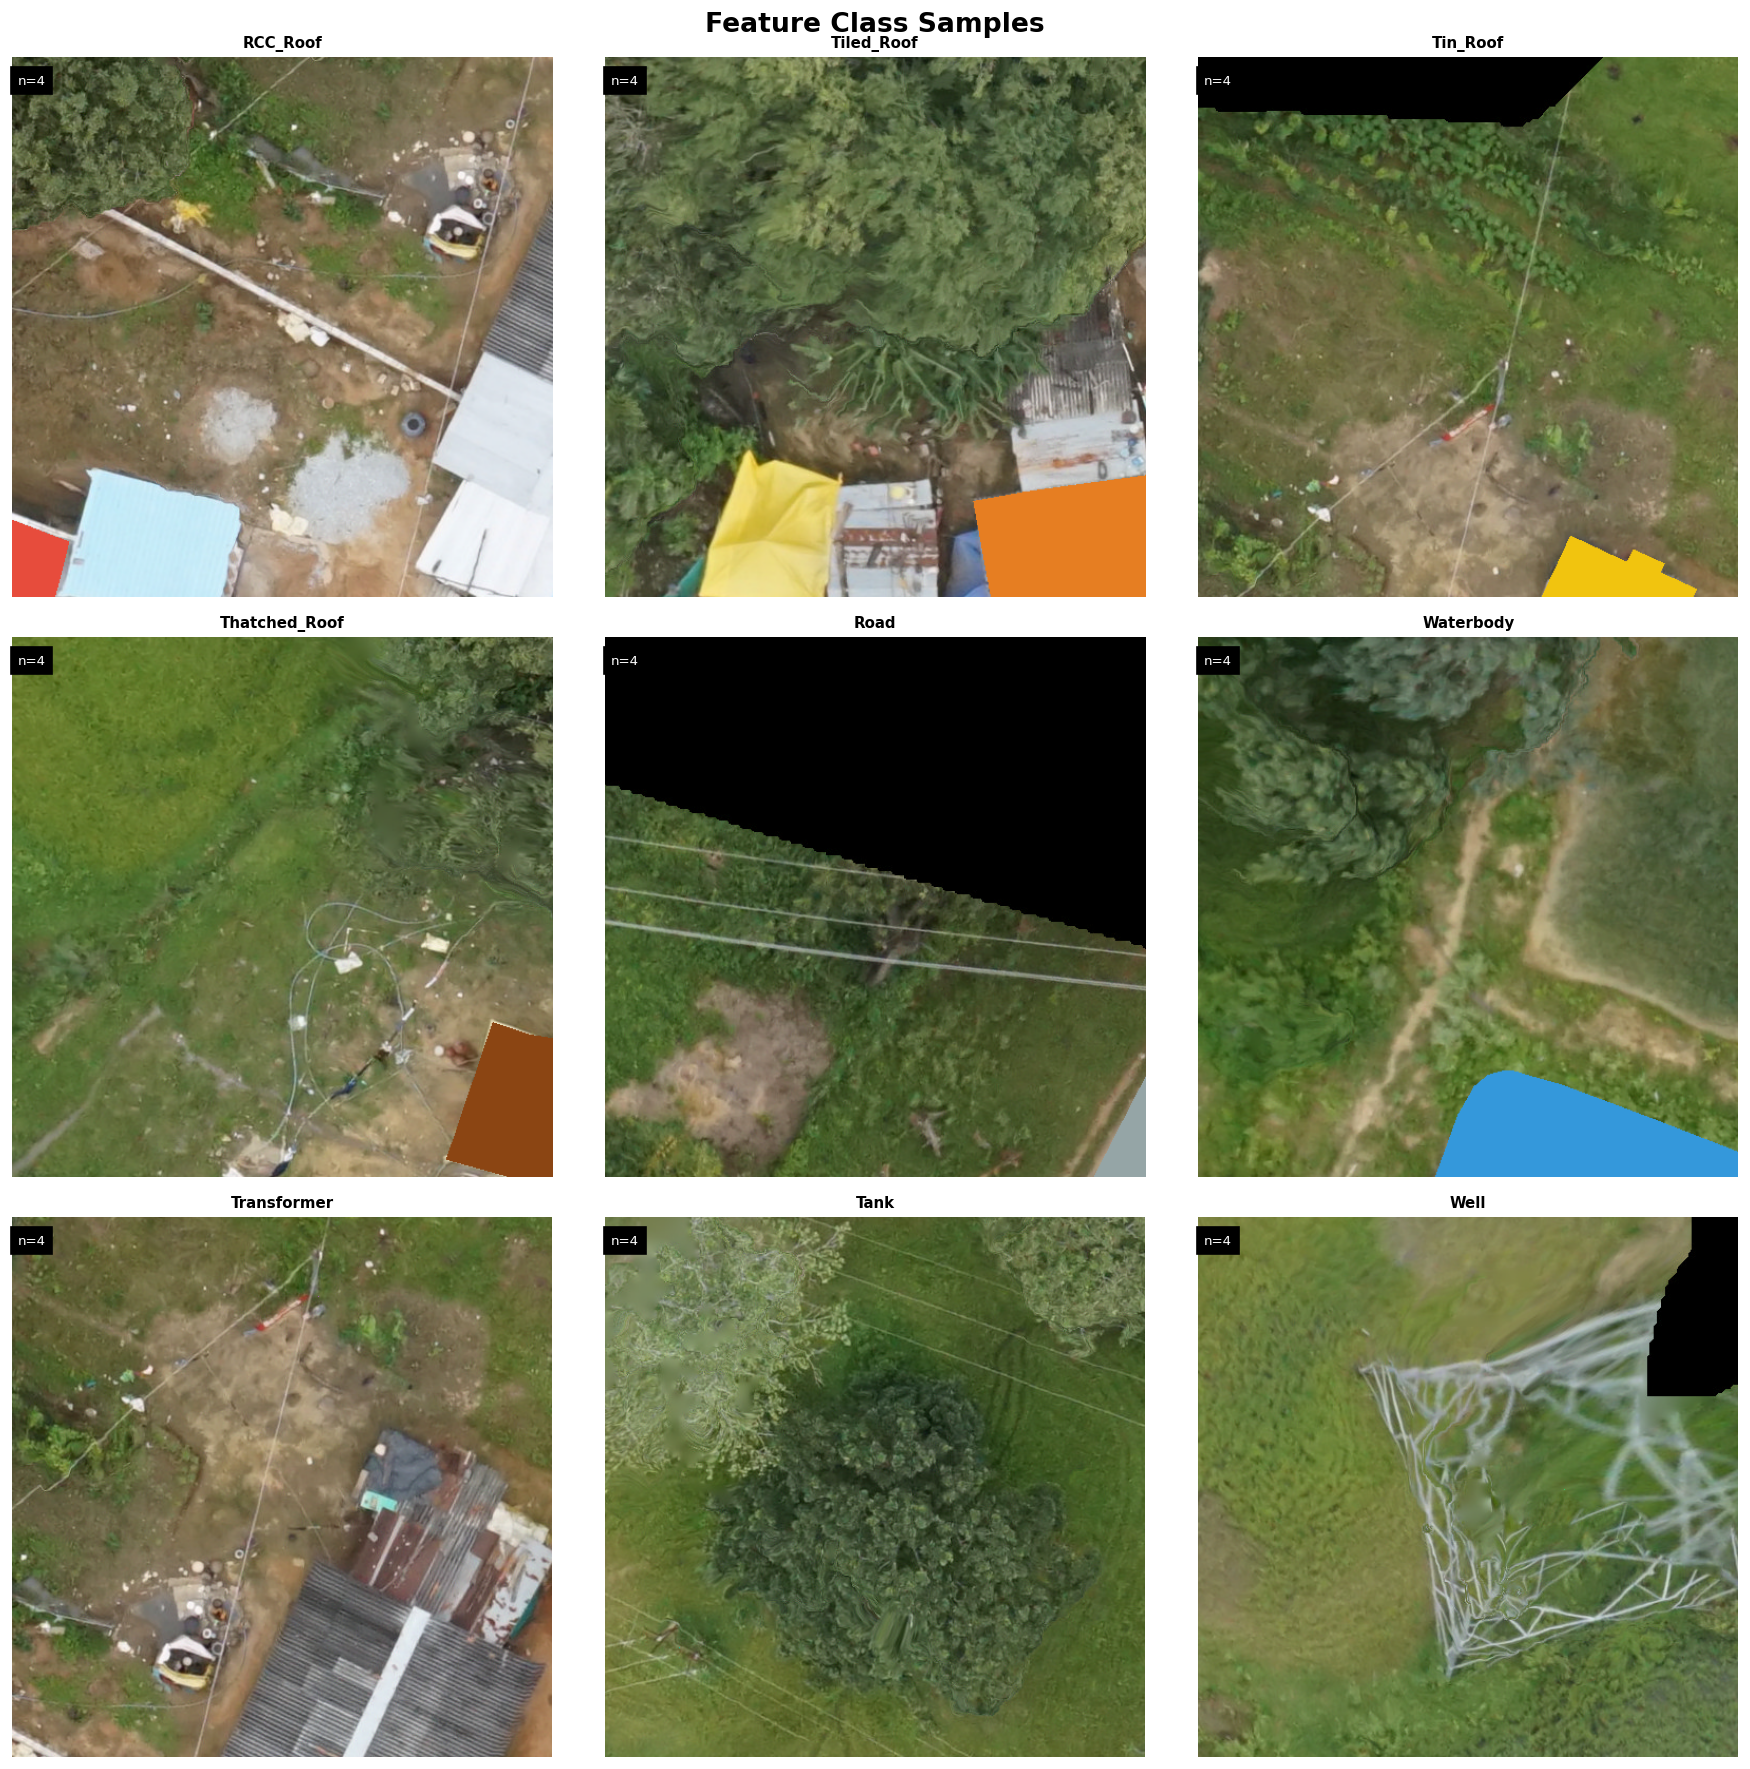

## final_analysis.png

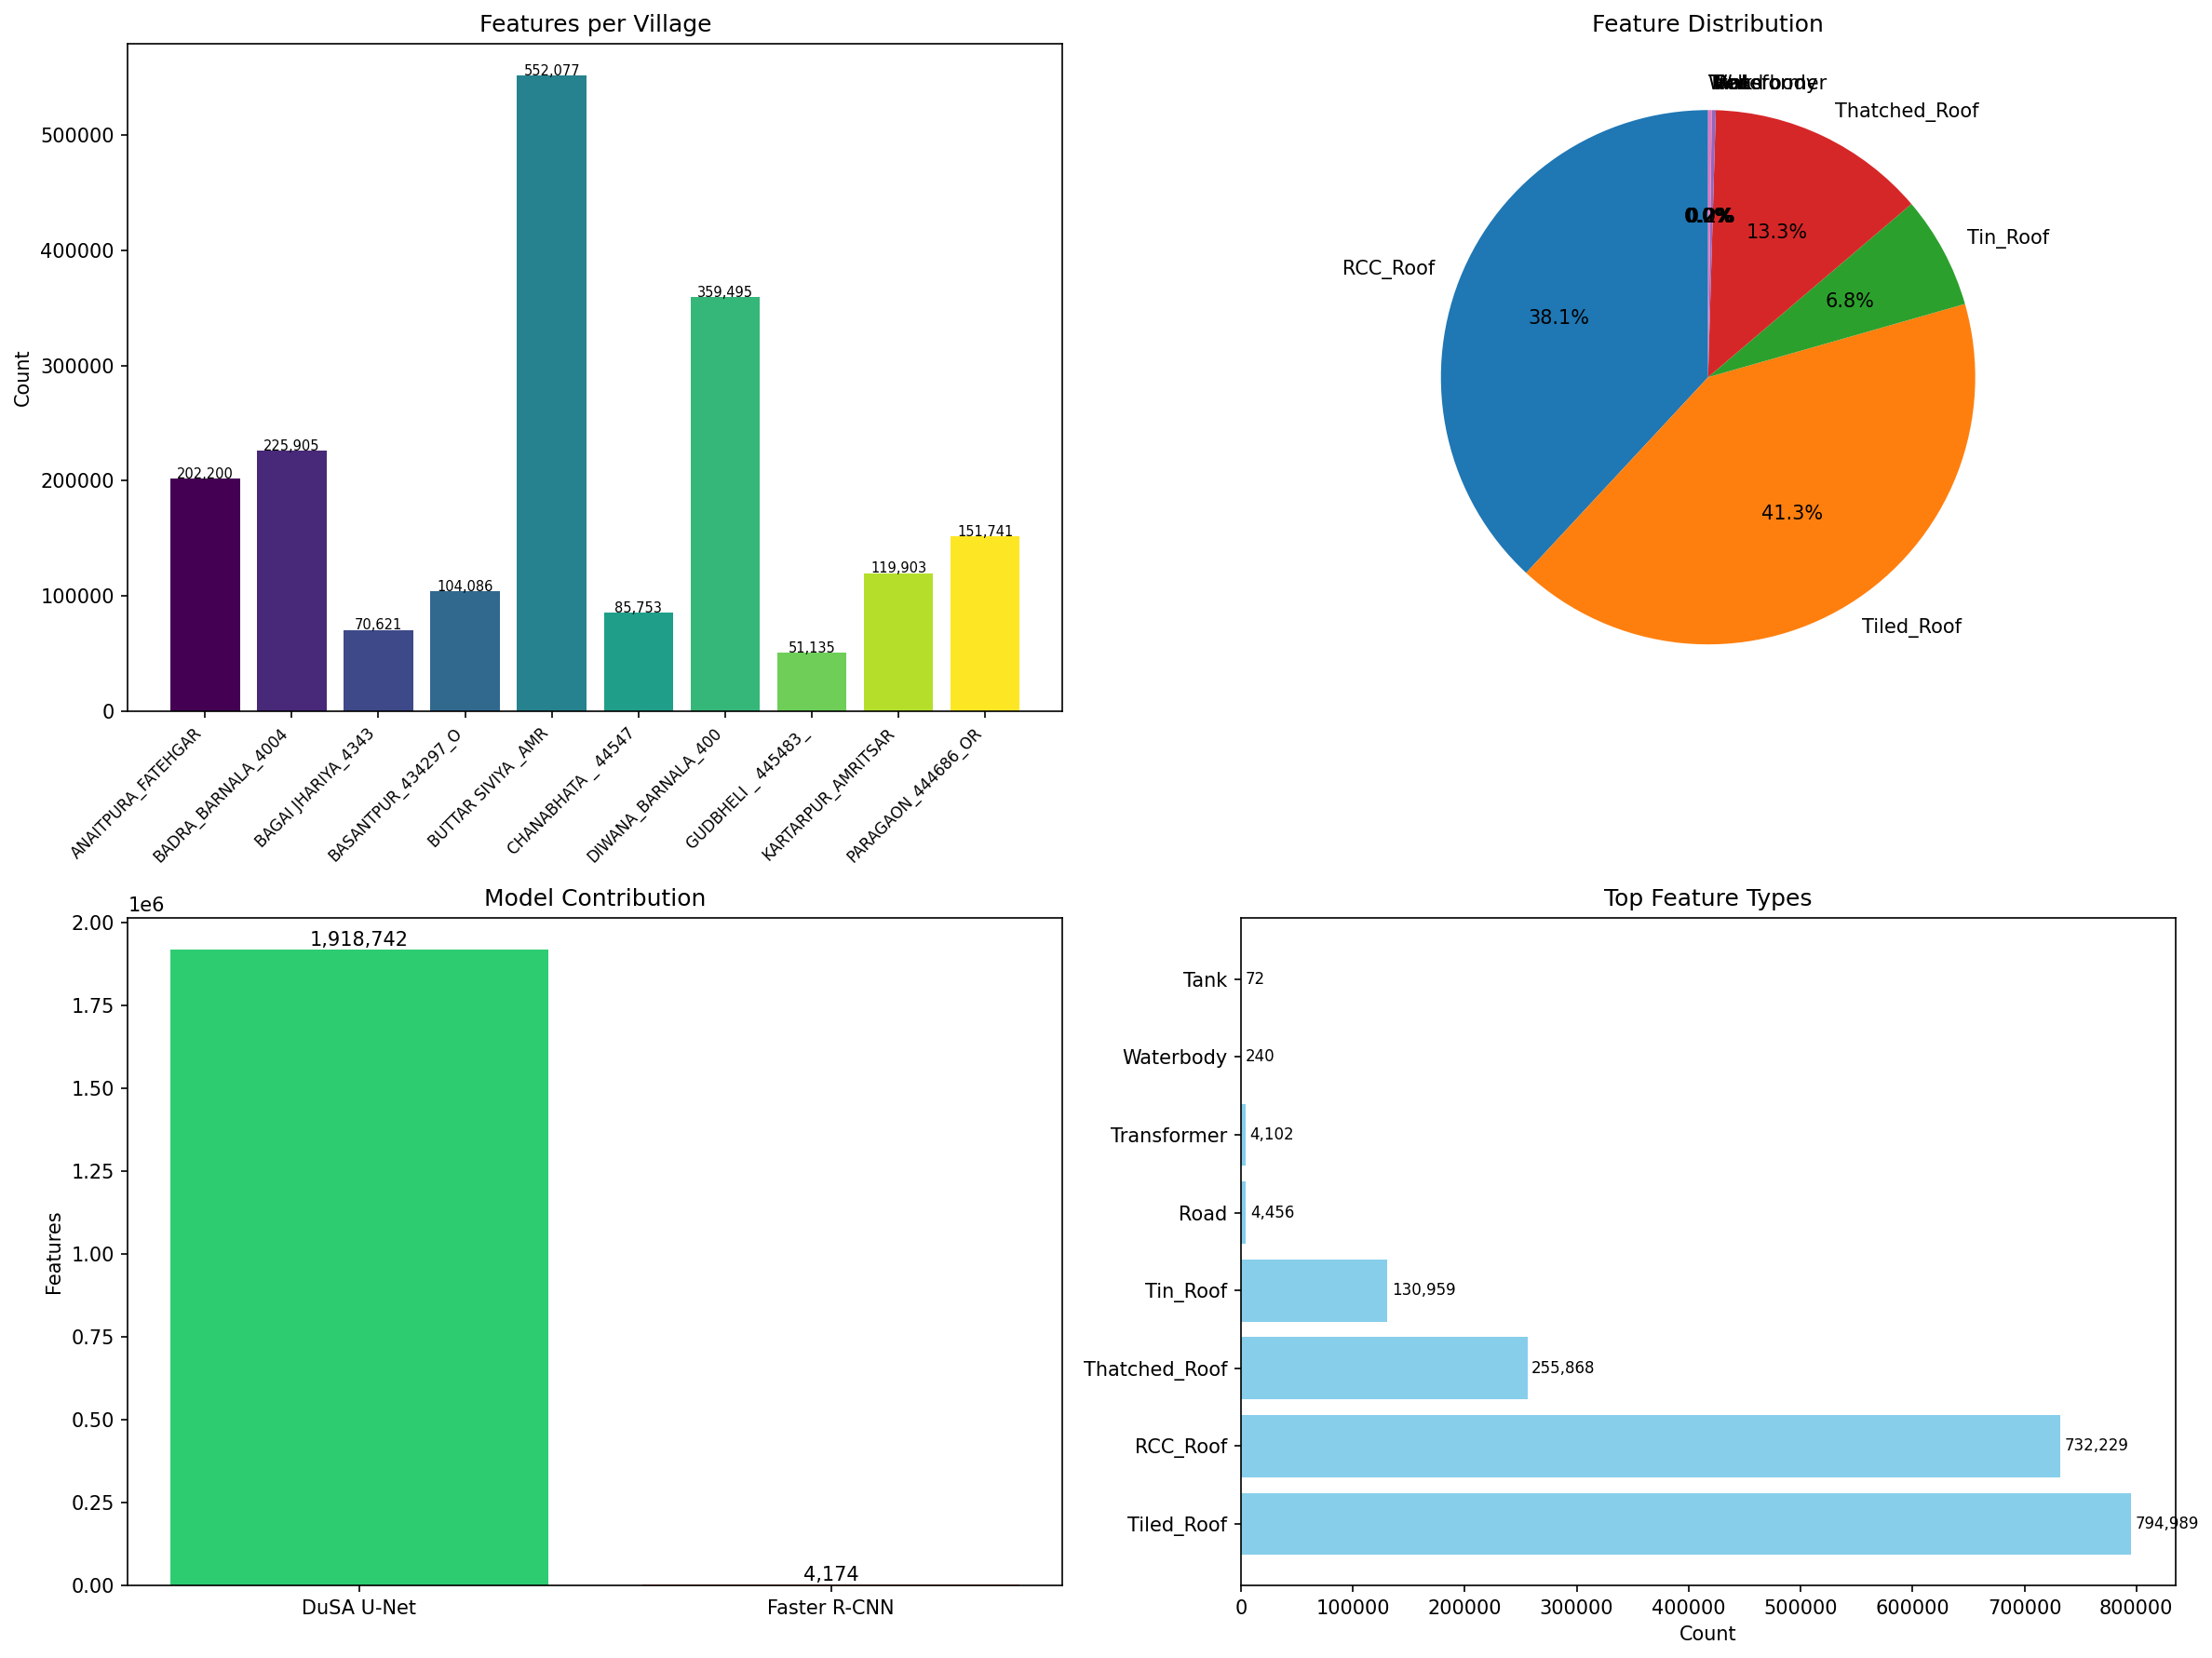

## geopackage_visualization.png

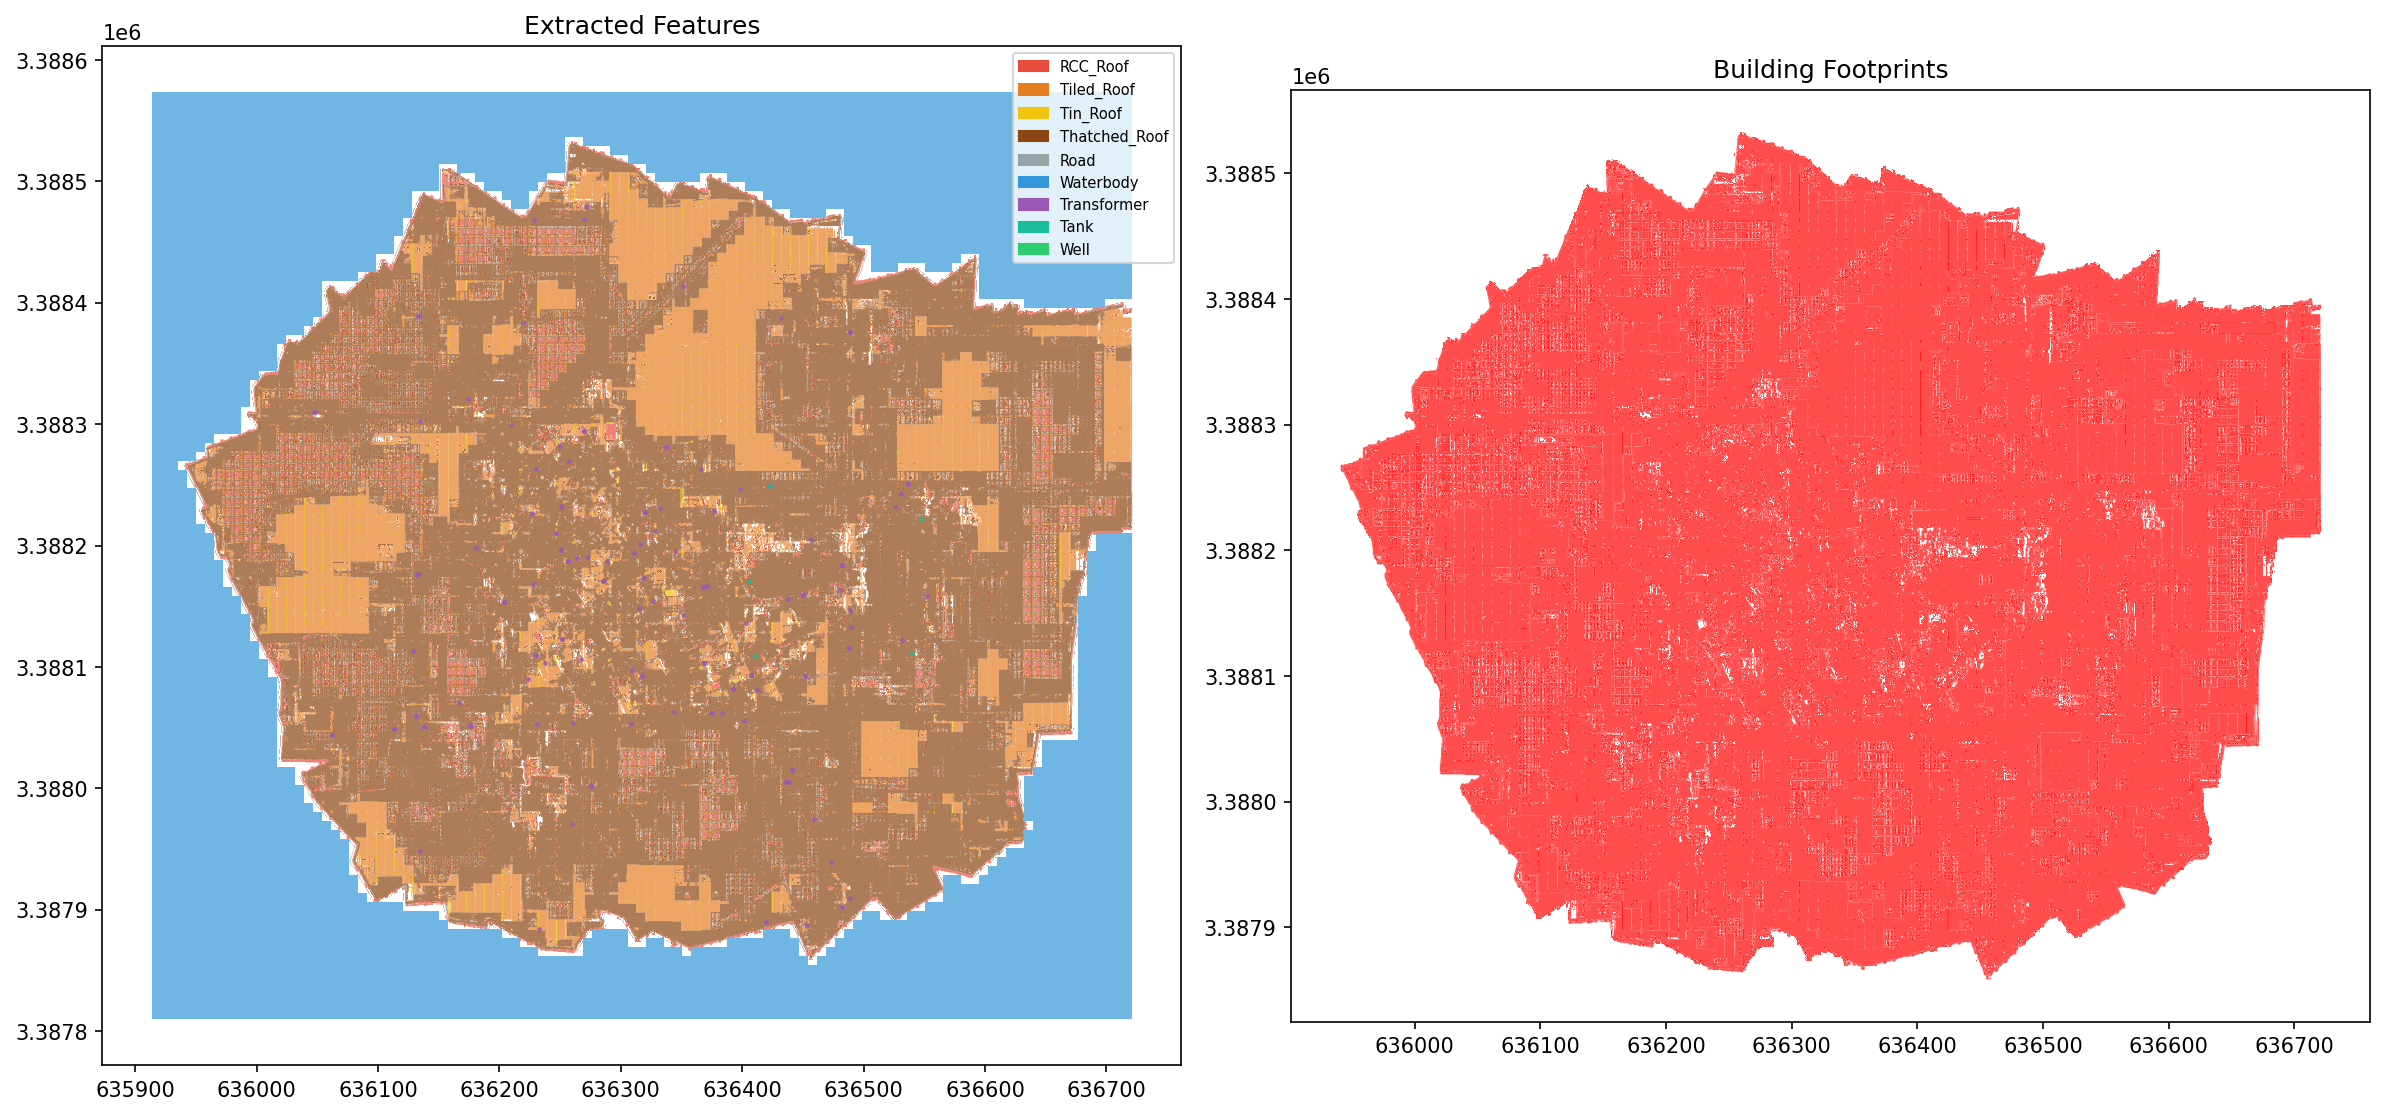

In [18]:
import os, glob
from IPython.display import display, Image, Markdown

BASE = ""

# All visualization files generated by your pipeline
patterns = [
    "final_analysis.png",
    "geopackage_visualization.png",
    "/nfsshare/users/manjula/svamitva_project/samples/all_features_composite.png",
    "samples/*.png",
    "outputs/**/*.png",
]

files = []
for p in patterns:
    files.extend(glob.glob(p, recursive=True))

files = sorted(list(set(files)))

print(f"Total visualizations found: {len(files)}")

for f in files:
    display(Markdown(f"## {f}"))
    display(Image(filename=f))

In [1]:
"""
SVAMITVA Project — Complete Pipeline
=====================================
Stage 1  Mask generation  ->  data/training/masks_raster/
Stage 2  Patch extraction ->  data/training/patches/{images,masks}/
Stage 3  Augmentation     ->  same patch dirs (minority classes)
Stage 4  Train DuSA U-Net ->  outputs/best_model.pth          [100 epochs]
Stage 5  Train R-CNN      ->  outputs/final/faster_rcnn_utilities.pth
Stage 6  Inference        ->  outputs/predictions/ + outputs/rcnn_utilities/
Stage 7  Merge+Eval+Vis   ->  outputs/final_predictions/ + charts

Usage
-----
python svamitva_pipeline.py --stage all      # full run
python svamitva_pipeline.py --stage 1        # masks only
python svamitva_pipeline.py --stage 1,2,3    # comma list
python svamitva_pipeline.py --stage 4,5      # training only
"""

# stdlib
import argparse, glob, os, random, sys, warnings
from collections import defaultdict

warnings.filterwarnings("ignore")
random.seed(42)

HPC_PROJECT = "/nfsshare/users/manjula/svamitva_project"
if os.path.isdir(HPC_PROJECT):
    sys.path.insert(0, HPC_PROJECT)

# ============================================================
# SHARED CONSTANTS
# ============================================================

CLASS_NAMES = {
    0: "Background", 1: "RCC_Roof",  2: "Tiled_Roof",  3: "Tin_Roof",
    4: "Thatched_Roof", 5: "Road",   6: "Waterbody",   7: "Transformer",
    8: "Tank",          9: "Well",
}

MODEL_SOURCES = {
    "RCC_Roof":      "DuSA U-Net",
    "Tiled_Roof":    "DuSA U-Net",
    "Tin_Roof":      "DuSA U-Net",
    "Thatched_Roof": "DuSA U-Net",
    "Road":          "DuSA U-Net",
    "Waterbody":     "DuSA U-Net",
    "Transformer":   "Faster R-CNN",
    "Tank":          "Faster R-CNN",
    "Well":          "DuSA U-Net",
}

FEATURE_COLORS = {
    1: {"name": "RCC_Roof",      "hex": "#E74C3C", "rgb": (231,  76,  60)},
    2: {"name": "Tiled_Roof",    "hex": "#E67E22", "rgb": (230, 126,  34)},
    3: {"name": "Tin_Roof",      "hex": "#F1C40F", "rgb": (241, 196,  15)},
    4: {"name": "Thatched_Roof", "hex": "#8B4513", "rgb": (139,  69,  19)},
    5: {"name": "Road",          "hex": "#95A5A6", "rgb": (149, 165, 166)},
    6: {"name": "Waterbody",     "hex": "#3498DB", "rgb": ( 52, 152, 219)},
    7: {"name": "Transformer",   "hex": "#9B59B6", "rgb": (155,  89, 182)},
    8: {"name": "Tank",          "hex": "#1ABC9C", "rgb": ( 26, 188, 156)},
    9: {"name": "Well",          "hex": "#2ECC71", "rgb": ( 46, 204, 113)},
}

WORKING_VILLAGES = ["BADETUMNAR", "MURDANDA", "NAGUL", "28996", "PINDORI", "TIMMOWAL"]

# ── Paths (unchanged — running on friend's HPC) ───────────────────────────────
DATA_ROOT = f"{HPC_PROJECT}/data"

PATHS = {
    "train_images": f"{DATA_ROOT}/training/images",
    "train_masks":  f"{DATA_ROOT}/training/masks_raster",
    "patch_images": f"{DATA_ROOT}/training/patches/images",
    "patch_masks":  f"{DATA_ROOT}/training/patches/masks",
    "test_images":  f"{DATA_ROOT}/testing/images",
    "unet_out":     f"{HPC_PROJECT}/outputs/predictions",
    "rcnn_out":     f"{HPC_PROJECT}/outputs/rcnn_utilities",
    "final_out":    f"{HPC_PROJECT}/outputs/final_predictions",
    "unet_model":   f"{HPC_PROJECT}/outputs/best_model.pth",
    "rcnn_model":   f"{HPC_PROJECT}/outputs/final/faster_rcnn_utilities.pth",
    "samples":      f"{HPC_PROJECT}/samples",
}

_SHP_CANDIDATES = [
    f"{HPC_PROJECT}/data/training/masks",
    f"{HPC_PROJECT}/data/raw/shp-file",
    f"{HPC_PROJECT}/data/raw/PB_training_dataSet_shp_file",
]

# ── Epoch counts (only change here if you need to adjust again) ───────────────
UNET_TOTAL_EPOCHS = 100   # ← changed from 50 → 100
RCNN_TOTAL_EPOCHS = 40    # unchanged

def _banner(t):
    print("\n" + "=" * 70 + "\n" + t + "\n" + "=" * 70)

def _mkdirs(*dirs):
    for d in dirs:
        os.makedirs(d, exist_ok=True)

def _find_shp():
    for d in _SHP_CANDIDATES:
        if os.path.isdir(d):
            return d
    return None

# ============================================================
# STAGE 1 — MASK GENERATION
# ============================================================

def stage1_mask_generation():
    _banner("STAGE 1 — MASK GENERATION")
    import numpy as np
    import rasterio
    from rasterio import features as rf
    import geopandas as gpd
    from shapely.geometry import box as sbox

    shp_dir = _find_shp()
    if not shp_dir:
        print("ERROR: shapefile directory not found. Checked:")
        for p in _SHP_CANDIDATES:
            print("  ", p)
        return False

    tifs = sorted(glob.glob(os.path.join(PATHS["train_images"], "*.tif")))
    if not tifs:
        print("ERROR: no .tif files in", PATHS["train_images"])
        return False

    print(f"  Shapefiles : {shp_dir}")
    print(f"  Images     : {len(tifs)}")

    # Load shapefiles once
    layers = {}
    for fname, cid in [
        ("Built_Up_Area_type.shp", None),
        ("Built_Up_Area_typ.shp",  None),
        ("Road.shp",               5),
        ("Water_Body.shp",         6),
        ("Utility.shp",            7),
    ]:
        p = os.path.join(shp_dir, fname)
        if os.path.exists(p):
            layers[fname] = (gpd.read_file(p), cid)
            print(f"  Loaded {fname} ({len(layers[fname][0])} rows)")
        else:
            print(f"  WARNING: {fname} not found in {shp_dir}")

    _mkdirs(PATHS["train_masks"])
    ok = 0
    for tif in tifs:
        stem = os.path.splitext(os.path.basename(tif))[0]
        out  = os.path.join(PATHS["train_masks"], f"{stem}_mask.tif")
        if os.path.exists(out):
            print(f"  {stem}: already exists — skipping")
            ok += 1
            continue
        try:
            with rasterio.open(tif) as src:
                H, W   = src.height, src.width
                tfm    = src.transform
                meta   = src.meta.copy()
                bounds = sbox(*src.bounds)

            mask = np.zeros((H, W), dtype=np.uint8)

            for fname, (gdf, cid) in layers.items():
                gdf_f = gdf[gdf.intersects(bounds)]
                if gdf_f.empty:
                    continue
                if "Built_Up_Area_type" in fname:
                    rm = {1: 1, 2: 2, 3: 3, 4: 4}
                    shapes = [
                        (r.geometry, rm.get(int(r["Roof_type"]), 1))
                        for _, r in gdf_f.iterrows() if r.geometry
                    ]
                else:
                    shapes = [(g, cid) for g in gdf_f.geometry if g]
                if shapes:
                    burned = rf.rasterize(
                        shapes, out_shape=(H, W),
                        transform=tfm, fill=0, dtype=np.uint8)
                    mask = np.maximum(mask, burned)

            meta.update(dtype=rasterio.uint8, count=1, compress="lzw", nodata=None)
            meta.pop("photometric", None)
            with rasterio.open(out, "w", **meta) as dst:
                dst.write(mask, 1)
            print(f"  {stem}_mask.tif  fg={int(np.sum(mask > 0)):,}")
            ok += 1
        except Exception as e:
            print(f"  ERROR {stem}: {e}")

    print(f"\n  Done: {ok}/{len(tifs)} masks → {PATHS['train_masks']}/")
    return ok > 0

# ============================================================
# STAGE 2 — PATCH EXTRACTION
# ============================================================

def stage2_patch_extraction():
    _banner("STAGE 2 — PATCH EXTRACTION")
    import numpy as np
    import rasterio
    from rasterio.windows import Window
    from PIL import Image

    PS, ST = 512, 256
    _mkdirs(PATHS["patch_images"], PATHS["patch_masks"])

    all_masks = sorted(glob.glob(os.path.join(PATHS["train_masks"], "*.tif")))
    if not all_masks:
        print("ERROR: no masks in", PATHS["train_masks"], "— run Stage 1 first.")
        return False

    pairs = []
    for mp in all_masks:
        stem     = os.path.splitext(os.path.basename(mp))[0]
        img_stem = stem[:-5] if stem.endswith("_mask") else stem
        if not any(v.upper() in img_stem.upper() for v in WORKING_VILLAGES):
            continue
        ip = os.path.join(PATHS["train_images"], f"{img_stem}.tif")
        if not os.path.exists(ip):
            print(f"  WARNING: image not found for {os.path.basename(mp)}")
            continue
        pairs.append((ip, mp, img_stem))

    if not pairs:
        print("ERROR: no village pairs found.")
        print("  Available masks:", [os.path.basename(m) for m in all_masks[:10]])
        return False

    total_new = 0
    for img_path, mask_path, stem in pairs:
        exist = len(glob.glob(os.path.join(PATHS["patch_images"], f"{stem}_*.png")))
        new = skip = 0
        try:
            with rasterio.open(img_path) as isrc, rasterio.open(mask_path) as msrc:
                H, W, nb = isrc.height, isrc.width, isrc.count
                print(f"  [{stem}] {W}×{H}  existing={exist}")
                for y in range(0, H - PS + 1, ST):
                    for x in range(0, W - PS + 1, ST):
                        pn = f"{stem}_{y}_{x}.png"
                        pi = os.path.join(PATHS["patch_images"], pn)
                        pm = os.path.join(PATHS["patch_masks"],  pn)
                        if os.path.exists(pi):
                            skip += 1
                            continue
                        win = Window(x, y, PS, PS)
                        ip_ = isrc.read(window=win)
                        mp_ = msrc.read(1, window=win)
                        if mp_.max() == 0:
                            skip += 1
                            continue
                        ip_ = ip_[:3] if nb >= 3 else np.repeat(ip_, 3, axis=0)
                        ip_ = np.transpose(ip_, (1, 2, 0)).astype(np.float32)
                        lo, hi = ip_.min(), ip_.max()
                        ip_ = ((ip_ - lo) / (hi - lo + 1e-8) * 255).astype(np.uint8)
                        Image.fromarray(ip_).save(pi)
                        Image.fromarray(mp_).save(pm)
                        new += 1
        except Exception as e:
            print(f"  ERROR {stem}: {e}")
            continue
        print(f"    new={new}  skipped={skip}")
        total_new += new

    total = len(glob.glob(os.path.join(PATHS["patch_images"], "*.png")))
    print(f"\n  New={total_new}  Total on disk={total:,}")
    return total > 0

# ============================================================
# STAGE 3 — AUGMENTATION
# ============================================================

def stage3_augmentation():
    _banner("STAGE 3 — MINORITY-CLASS AUGMENTATION")
    import numpy as np
    import cv2

    # (class_pixel_value, label, augments_per_source)
    TARGETS = {8: ("Tank", 5), 9: ("Well", 65)}
    idir = PATHS["patch_images"]
    mdir = PATHS["patch_masks"]

    for cval, (label, n) in TARGETS.items():
        srcs = []
        for f in sorted(os.listdir(idir)):
            if f.startswith("aug_"):
                continue
            mp = os.path.join(mdir, f)
            if not os.path.exists(mp):
                continue
            m = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
            if m is not None and cval in np.unique(m):
                srcs.append(f)
        print(f"\n  {label}: {len(srcs)} sources × {n} = {len(srcs)*n} augments")
        if not srcs:
            print("  WARNING: no source patches found for", label)
            continue
        cnt = 0
        for f in srcs:
            img  = cv2.imread(os.path.join(idir, f))
            mask = cv2.imread(os.path.join(mdir, f), cv2.IMREAD_GRAYSCALE)
            if img is None or mask is None:
                continue
            for _ in range(n):
                fl = random.choice([-2, -1, 0, 1])
                ai = cv2.flip(img,  fl) if fl != -2 else img.copy()
                am = cv2.flip(mask, fl) if fl != -2 else mask.copy()
                ai = cv2.convertScaleAbs(
                    ai,
                    alpha=random.uniform(0.7, 1.4),
                    beta=random.uniform(-40, 40))
                nf = f"aug_{label.lower()}_{cnt}_{f}"
                cv2.imwrite(os.path.join(idir, nf), ai)
                cv2.imwrite(os.path.join(mdir, nf), am)
                cnt += 1
        print(f"  Generated {cnt} augmented patches for {label}")

    total = len(glob.glob(os.path.join(idir, "*.png")))
    print(f"\n  Total patches after augmentation: {total:,}")
    return True

# ============================================================
# STAGE 4 — TRAIN DuSA U-Net  (100 epochs)
# ============================================================

def stage4_train_unet():
    _banner(f"STAGE 4 — TRAIN DuSA U-Net  [{UNET_TOTAL_EPOCHS} epochs]")
    import numpy as np
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import Dataset, DataLoader, Subset
    from PIL import Image
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    from models.dusa_unet import DuSA_UNet

    os.environ["CUDA_VISIBLE_DEVICES"]       = "5"
    os.environ["PYTORCH_CUDA_ALLOC_CONF"]    = "expandable_segments:True"
    torch.manual_seed(42)
    np.random.seed(42)

    AUG_TR = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.RandomGamma(p=0.3),
        A.GaussNoise(p=0.2),
        A.ElasticTransform(p=0.2, alpha=1, sigma=50),
        A.CLAHE(p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])
    AUG_VA = A.Compose([
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

    class PDS(Dataset):
        def __init__(self, aug):
            self.imgs  = sorted(glob.glob(os.path.join(PATHS["patch_images"], "*.png")))
            self.masks = sorted(glob.glob(os.path.join(PATHS["patch_masks"],  "*.png")))
            self.aug   = aug
        def __len__(self):
            return len(self.imgs)
        def __getitem__(self, i):
            img  = np.array(Image.open(self.imgs[i]).convert("RGB"))
            mask = np.clip(np.array(Image.open(self.masks[i])), 0, 9)
            out  = self.aug(image=img, mask=mask)
            return out["image"], out["mask"].long()

    n = len(glob.glob(os.path.join(PATHS["patch_images"], "*.png")))
    if n == 0:
        print("ERROR: no patches found. Run Stages 1-3 first.")
        return False

    idx = list(range(n))
    random.shuffle(idx)
    vn   = int(0.2 * n)
    tr_i = idx[vn:]
    va_i = idx[:vn]
    tr_ds = Subset(PDS(AUG_TR), tr_i)
    va_ds = Subset(PDS(AUG_VA), va_i)
    tr_ld = DataLoader(tr_ds, batch_size=16, shuffle=True,  num_workers=8,
                       pin_memory=True, persistent_workers=True)
    va_ld = DataLoader(va_ds, batch_size=16, shuffle=False, num_workers=8,
                       pin_memory=True, persistent_workers=True)
    print(f"  Train={len(tr_ds):,}  Val={len(va_ds):,}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = DuSA_UNet(n_classes=10).to(device)
    print(f"  Device={device}  Params={sum(p.numel() for p in model.parameters())/1e6:.2f}M")

    # Resume from checkpoint if one exists
    # start_epoch is set to the epoch after the last saved checkpoint
    start = 0
    best  = 0.0
    for ck in [PATHS["unet_model"], "outputs/best_model_resumed.pth"]:
        if os.path.exists(ck):
            model.load_state_dict(torch.load(ck, map_location=device))
            # If a 50-epoch run completed previously, resume from epoch 50
            start = 50
            best  = 91.75
            print(f"  Resumed from checkpoint: {ck}  (continuing from epoch {start+1})")
            break

    class LabelSmoothCE(nn.Module):
        def __init__(self, s=0.1):
            super().__init__()
            self.s = s
        def forward(self, p, t):
            nc = p.size(1)
            lp = nn.functional.log_softmax(p, dim=1)
            with torch.no_grad():
                td = torch.full_like(p, self.s / (nc - 1))
                td.scatter_(1, t.unsqueeze(1), 1 - self.s)
            return (-td * lp).sum(1).mean()

    crit   = LabelSmoothCE(0.1)
    opt    = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

    # OneCycleLR over the full 100-epoch budget.
    # last_epoch lets us resume mid-schedule correctly.
    steps_per_epoch = len(tr_ld)
    total_steps = steps_per_epoch * UNET_TOTAL_EPOCHS

# Fresh scheduler creation (safe for resumed training)
    sch = optim.lr_scheduler.OneCycleLR(
        opt,
        max_lr=1e-3,
        total_steps=total_steps,
        pct_start=0.1,
        anneal_strategy="cos"
    )

# Advance scheduler manually if resuming
    if start > 0:
        for _ in range(start * steps_per_epoch):
            sch.step()
    scaler = torch.cuda.amp.GradScaler()
    _mkdirs("outputs")

    print(f"\n  Starting epoch {start + 1}/{UNET_TOTAL_EPOCHS}  "
          f"best_so_far={best:.2f}%\n")
    print(f"  {'Ep':>4}  {'TrLoss':>8}  {'VlLoss':>8}  {'Acc':>8}")
    print("  " + "-" * 38)

    for epoch in range(start, UNET_TOTAL_EPOCHS):
        # ── training ──
        model.train()
        tl = 0.0
        for imgs, masks in tr_ld:
            imgs, masks = imgs.to(device), masks.to(device)
            opt.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast():
                loss = crit(model(imgs), masks)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
            sch.step()
            tl += loss.item()
        tl /= len(tr_ld)

        # ── validation ──
        model.eval()
        correct = total = 0
        vl = 0.0
        with torch.no_grad():
            for imgs, masks in va_ld:
                imgs, masks = imgs.to(device), masks.to(device)
                with torch.cuda.amp.autocast():
                    out  = model(imgs)
                    loss = crit(out, masks)
                vl    += loss.item()
                pred   = torch.argmax(out, 1)
                correct += (pred == masks).sum().item()
                total   += masks.numel()
        vl  /= len(va_ld)
        acc  = correct / total * 100

        flag = ""
        if acc > best:
            best = acc
            torch.save(model.state_dict(), PATHS["unet_model"])
            flag = "  ← best"

        print(f"  {epoch+1:>4}  {tl:>8.4f}  {vl:>8.4f}  {acc:>7.2f}%{flag}")
        torch.cuda.empty_cache()

    print(f"\n  ✅ Training complete  —  Best accuracy: {best:.2f}%")
    print(f"  Model saved → {PATHS['unet_model']}")
    return True

# ============================================================
# STAGE 5 — TRAIN Faster R-CNN  (40 epochs, unchanged)
# ============================================================

def stage5_train_rcnn():
    _banner(f"STAGE 5 — TRAIN Faster R-CNN ({RCNN_TOTAL_EPOCHS} epochs)")
    import math
    import numpy as np
    import torch
    import cv2
    from torch.utils.data import Dataset, DataLoader, Subset
    from torchvision import transforms as T
    from torchvision.models.detection import fasterrcnn_resnet50_fpn
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    from torchvision.models.detection.anchor_utils import AnchorGenerator
    from tqdm import tqdm

    os.environ["CUDA_VISIBLE_DEVICES"] = "6"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"  Device: {device}")

    KERNEL = np.ones((17, 17), np.uint8)
    M2C    = {7: 1, 8: 2, 9: 3}   # mask value → class id

    class UDS(Dataset):
        def __init__(self):
            self.imgs = sorted(os.listdir(PATHS["patch_images"]))
        def __len__(self): return len(self.imgs)
        def __getitem__(self, idx):
            f    = self.imgs[idx]
            img  = cv2.cvtColor(
                cv2.imread(os.path.join(PATHS["patch_images"], f)),
                cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
            mask = cv2.imread(os.path.join(PATHS["patch_masks"], f),
                              cv2.IMREAD_GRAYSCALE)
            boxes, labels = [], []
            for mv, ci in M2C.items():
                bm = cv2.dilate((mask == mv).astype(np.uint8), KERNEL, iterations=1)
                try:
                    nl, _, stats, _ = cv2.connectedComponentsWithStats(bm, connectivity=8)
                except cv2.error:
                    continue
                for i in range(1, nl):
                    x, y = stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP]
                    w, h = stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT]
                    if w >= 2 and h >= 2:
                        boxes.append([float(x), float(y), float(x+w), float(y+h)])
                        labels.append(ci)
            boxes  = torch.as_tensor(boxes,  dtype=torch.float32)
            labels = torch.as_tensor(labels, dtype=torch.int64)
            iid    = torch.tensor([idx])
            if len(boxes):
                tgt = {
                    "boxes":   boxes, "labels": labels, "image_id": iid,
                    "area":    (boxes[:,3]-boxes[:,1])*(boxes[:,2]-boxes[:,0]),
                    "iscrowd": torch.zeros(len(boxes), dtype=torch.int64),
                }
            else:
                tgt = {
                    "boxes":   torch.zeros((0,4), dtype=torch.float32),
                    "labels":  torch.zeros((0,),  dtype=torch.int64),
                    "image_id": iid,
                    "area":    torch.zeros((0,),  dtype=torch.float32),
                    "iscrowd": torch.zeros((0,),  dtype=torch.int64),
                }
            return T.ToTensor()(img), tgt

    def colfn(b): return tuple(zip(*b))

    def get_rcnn(nc=4):
        anc = AnchorGenerator(
            sizes=((16,),(32,),(64,),(128,),(256,)),
            aspect_ratios=((0.5, 1.0, 2.0),) * 5)
        m = fasterrcnn_resnet50_fpn(
            weights="DEFAULT", rpn_anchor_generator=anc, box_nms_thresh=0.2)
        inf = m.roi_heads.box_predictor.cls_score.in_features
        m.roi_heads.box_predictor = FastRCNNPredictor(inf, nc)
        return m

    full        = UDS()
    masks_list  = sorted(os.listdir(PATHS["patch_masks"]))
    print("  Scanning for utility patches …")
    ui, ei = [], []
    for i, f in enumerate(tqdm(masks_list, desc="scan")):
        m = cv2.imread(os.path.join(PATHS["patch_masks"], f), cv2.IMREAD_GRAYSCALE)
        if m is None: continue
        has = False
        if np.any(np.isin(m, [7, 8, 9])):
            for mv in [7, 8, 9]:
                bm = cv2.dilate((m == mv).astype(np.uint8), KERNEL, iterations=1)
                try:
                    nl, _, stats, _ = cv2.connectedComponentsWithStats(bm, connectivity=8)
                    for j in range(1, nl):
                        if (stats[j, cv2.CC_STAT_WIDTH]  >= 2 and
                                stats[j, cv2.CC_STAT_HEIGHT] >= 2):
                            has = True; break
                except cv2.error:
                    pass
                if has: break
        (ui if has else ei).append(i)

    ne = int(len(ui) * 0.20)
    random.shuffle(ei)
    active = ui + ei[:ne]
    print(f"  Utility={len(ui)}  Hard-neg={ne}  Total active={len(active)}")
    sub = Subset(full, active)
    tn  = int(0.8 * len(sub))
    gen = torch.Generator().manual_seed(42)
    tr, va = torch.utils.data.random_split(sub, [tn, len(sub)-tn], generator=gen)
    tr_ld = DataLoader(tr, batch_size=2, shuffle=True,  num_workers=2, collate_fn=colfn)
    va_ld = DataLoader(va, batch_size=1, shuffle=False, num_workers=2, collate_fn=colfn)
    print(f"  Train={len(tr)}  Val={len(va)}")

    model  = get_rcnn(4).to(device)
    params = [p for p in model.parameters() if p.requires_grad]
    opt    = torch.optim.SGD(params, lr=5e-4, momentum=0.9, weight_decay=5e-4)
    sch    = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.2)
    _mkdirs("outputs/final")

    def cdist(b1, b2):
        return math.hypot(
            (b1[0]+b1[2])/2 - (b2[0]+b2[2])/2,
            (b1[1]+b1[3])/2 - (b2[1]+b2[3])/2)

    print(f"\n  {'Ep':>4}  {'Loss':>8}  {'Prec':>8}  {'Recall':>8}")
    print("  " + "-" * 36)

    for epoch in range(RCNN_TOTAL_EPOCHS):
        model.train(); el = 0.0
        for imgs, tgts in tr_ld:
            imgs = [i.to(device) for i in imgs]
            tgts = [{k: v.to(device) for k, v in t.items()} for t in tgts]
            ld   = model(imgs, tgts); loss = sum(ld.values())
            opt.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
            opt.step(); el += loss.item()
        sch.step()

        model.eval()
        cc = {1:0, 2:0, 3:0}; ct = {1:0, 2:0, 3:0}; cp = {1:0, 2:0, 3:0}
        with torch.no_grad():
            for vi, vt in va_ld:
                vi = [i.to(device) for i in vi]
                vt = [{k: v.to(device) for k, v in t.items()} for t in vt]
                out = model(vi)
                for i, o in enumerate(out):
                    gb = vt[i]["boxes"].cpu().numpy()
                    gl = vt[i]["labels"].cpu().numpy()
                    pb = o["boxes"].cpu().numpy()
                    pl = o["labels"].cpu().numpy()
                    ps = o["scores"].cpu().numpy()
                    keep = ps >= 0.50; pb = pb[keep]; pl = pl[keep]
                    for cls in [1, 2, 3]:
                        gb_c = gb[gl==cls]; pb_c = pb[pl==cls]
                        ct[cls] += len(gb_c); cp[cls] += len(pb_c)
                        mg = set()
                        for pb_i in pb_c:
                            bd, bi = 1e9, -1
                            for gi, gb_i in enumerate(gb_c):
                                if gi in mg: continue
                                d = cdist(pb_i, gb_i)
                                if d < bd: bd, bi = d, gi
                            if bd <= 10.0: cc[cls] += 1; mg.add(bi)

        tc  = sum(cc.values()); tg = sum(ct.values()); tp_ = sum(cp.values())
        pr  = tc / tp_ if tp_ else 0
        rc  = tc / tg  if tg  else 0
        print(f"  {epoch+1:>4}  {el/len(tr_ld):>8.4f}  {pr:>8.2%}  {rc:>8.2%}")
        torch.cuda.empty_cache()

    torch.save(model.state_dict(), PATHS["rcnn_model"])
    print(f"\n  ✅ Training complete — saved → {PATHS['rcnn_model']}")
    return True

# ============================================================
# STAGE 6 — INFERENCE
# ============================================================

def stage6_inference():
    _banner("STAGE 6 — INFERENCE ON TESTING VILLAGES")
    import numpy as np
    import torch
    import rasterio
    from rasterio import features as rf
    from rasterio.windows import Window
    import geopandas as gpd
    from shapely.geometry import shape, Point
    import cv2
    import pandas as pd
    from models.dusa_unet import DuSA_UNet
    from torchvision.models.detection import fasterrcnn_resnet50_fpn
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    from torchvision.models.detection.anchor_utils import AnchorGenerator

    os.environ["CUDA_VISIBLE_DEVICES"] = "6"
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    test_imgs = sorted(glob.glob(os.path.join(PATHS["test_images"], "*.tif")))
    if not test_imgs:
        print("ERROR: no test images in", PATHS["test_images"])
        return False
    print(f"  Test villages: {len(test_imgs)}")

    # Class-specific confidence thresholds (tuned on validation)
    THR = {1:0.45, 2:0.40, 3:0.50, 4:0.35, 5:0.55, 6:0.50, 7:0.30, 8:0.30, 9:0.30}

    def tta(model, p):
        """4-fold TTA: original + H-flip + V-flip + both."""
        preds = []
        with torch.no_grad():
            preds.append(model(p))
            for dims in ([3], [2], [2, 3]):
                fp = torch.flip(p, dims=dims); o = model(fp)
                for d in reversed(dims): o = torch.flip(o, dims=[d])
                preds.append(o)
        return torch.stack(preds).mean(0)

    def apply_thresholds(sm):
        v = torch.zeros_like(sm)
        for c, t in THR.items(): v[c] = (sm[c] > t).float()
        return torch.argmax(v, 0)

    def morph_clean(m, ks=3):
        k   = np.ones((ks, ks), np.uint8)
        m   = cv2.morphologyEx(m, cv2.MORPH_OPEN, k)
        m   = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k)
        cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            if cv2.contourArea(c) < 100: cv2.drawContours(m, [c], -1, 0, -1)
        return m

    # ── 6a: U-Net segmentation ────────────────────────────────────────────────
    if not os.path.exists(PATHS["unet_model"]):
        print("ERROR: U-Net model not found. Run Stage 4 first.")
        return False

    unet = DuSA_UNet(n_classes=10).to(device)
    unet.load_state_dict(torch.load(PATHS["unet_model"], map_location=device))
    unet.eval()
    _mkdirs(PATHS["unet_out"])
    FC = {k: v for k, v in CLASS_NAMES.items() if k > 0}
    PS, ST = 512, 256

    print("\n  [6a] U-Net segmentation ...")
    for ip in test_imgs:
        base = os.path.splitext(os.path.basename(ip))[0]
        out  = os.path.join(PATHS["unet_out"], f"{base}_features.gpkg")
        print(f"    {base} ...", end=" ", flush=True)
        try:
            with rasterio.open(ip) as src:
                H, W = src.height, src.width
                tfm, crs, nb = src.transform, src.crs, src.count
                pf = np.zeros((H, W), dtype=np.uint8)
                for y in range(0, H - PS + 1, ST):
                    for x in range(0, W - PS + 1, ST):
                        p = src.read(window=Window(x, y, PS, PS))
                        if nb == 4: p = p[:3]
                        elif nb == 1: p = np.repeat(p, 3, axis=0)
                        pt = torch.FloatTensor(p).unsqueeze(0).to(device)
                        sm = tta(unet, pt)
                        pr = apply_thresholds(sm[0])
                        pc = morph_clean(pr.cpu().numpy().astype(np.uint8))
                        pf[y:y+PS, x:x+PS] = np.maximum(pf[y:y+PS, x:x+PS], pc)
            feats = []
            for cid, cn in FC.items():
                cm = (pf == cid).astype(np.uint8)
                if not cm.any(): continue
                for g, v in rf.shapes(cm, transform=tfm):
                    if v == 1:
                        gs = shape(g)
                        feats.append({"geometry": gs, "class_id": cid,
                                      "class_name": cn, "area": gs.area})
            if feats:
                gpd.GeoDataFrame(feats, crs=crs).to_file(out, driver="GPKG")
            print(f"{len(feats):,}")
        except Exception as e:
            print(f"ERROR: {e}")
        torch.cuda.empty_cache()

    # ── 6b: Faster R-CNN utility detection ────────────────────────────────────
    if not os.path.exists(PATHS["rcnn_model"]):
        print("\n  WARNING: R-CNN model not found — skipping 6b")
    else:
        def get_r(nc=4):
            anc = AnchorGenerator(
                sizes=((16,),(32,),(64,),(128,),(256,)),
                aspect_ratios=((0.5, 1.0, 2.0),) * 5)
            m = fasterrcnn_resnet50_fpn(
                weights="DEFAULT", rpn_anchor_generator=anc, box_nms_thresh=0.2)
            inf = m.roi_heads.box_predictor.cls_score.in_features
            m.roi_heads.box_predictor = FastRCNNPredictor(inf, nc)
            return m

        rcnn = get_r(4).to(device)
        rcnn.load_state_dict(torch.load(PATHS["rcnn_model"], map_location=device))
        rcnn.eval()
        _mkdirs(PATHS["rcnn_out"])
        RC = {1: "Transformer", 2: "Tank", 3: "Well"}
        RP, RS = 1024, 512
        summary = []

        print("\n  [6b] R-CNN utility detection ...")
        for ip in test_imgs:
            base = os.path.splitext(os.path.basename(ip))[0]
            out  = os.path.join(PATHS["rcnn_out"], f"{base}_utilities.gpkg")
            print(f"    {base} ...", end=" ", flush=True)
            dets = []
            try:
                with rasterio.open(ip) as src:
                    H, W = src.height, src.width
                    tfm, crs = src.transform, src.crs
                    for y in range(0, H - RP + 1, RS):
                        for x in range(0, W - RP + 1, RS):
                            p = src.read(window=Window(x, y, RP, RS))
                            if p.shape[0] < 3: continue
                            rgb = np.transpose(p[:3], (1,2,0)).astype(np.float32)/255.0
                            pt  = torch.from_numpy(rgb).permute(2,0,1).unsqueeze(0).to(device)
                            with torch.no_grad(): pred_ = rcnn([pt[0]])[0]
                            for b, l, s in zip(pred_["boxes"].cpu().numpy(),
                                               pred_["labels"].cpu().numpy(),
                                               pred_["scores"].cpu().numpy()):
                                if s >= 0.3 and l in RC:
                                    cx = (b[0]+b[2])/2 + x
                                    cy = (b[1]+b[3])/2 + y
                                    lon, lat = tfm * (cx, cy)
                                    dets.append({
                                        "geometry":   Point(lon, lat),
                                        "class_name": RC[l],
                                        "confidence": float(s),
                                    })
                            torch.cuda.empty_cache()
                gdf = (gpd.GeoDataFrame(dets, crs=crs) if dets
                       else gpd.GeoDataFrame(
                           columns=["geometry", "class_name", "confidence"], crs=crs))
                gdf.to_file(out, driver="GPKG")
                print(f"{len(gdf)}")
                summary.append({
                    "Village":      base,
                    "Utilities":    len(gdf),
                    "Transformers": len(gdf[gdf.class_name == "Transformer"]) if len(gdf) else 0,
                    "Tanks":        len(gdf[gdf.class_name == "Tank"])        if len(gdf) else 0,
                    "Wells":        len(gdf[gdf.class_name == "Well"])        if len(gdf) else 0,
                })
            except Exception as e:
                print(f"ERROR: {e}")

        pd.DataFrame(summary).to_csv(
            os.path.join(PATHS["rcnn_out"], "rcnn_summary.csv"), index=False)

    print("\n  STAGE 6 COMPLETE")
    return True

# ============================================================
# STAGE 7 — MERGE / EVALUATE / VISUALISE
# ============================================================

def stage7_merge_evaluate_visualise():
    _banner("STAGE 7 — MERGE / EVALUATE / VISUALISE")
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import geopandas as gpd
    import torch
    from PIL import Image
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
    from torch.utils.data import Dataset, DataLoader

    # ── 7a: Merge GeoPackages ─────────────────────────────────────────────────
    print("\n[7a] Merging GeoPackages ...")
    _mkdirs(PATHS["final_out"])
    ug = sorted(glob.glob(os.path.join(PATHS["unet_out"],  "*_features.gpkg")))
    rm = {
        os.path.basename(f).replace("_utilities.gpkg", ""): f
        for f in glob.glob(os.path.join(PATHS["rcnn_out"], "*_utilities.gpkg"))
    }
    vstats = []
    tbc    = {v: 0 for k, v in CLASS_NAMES.items() if k > 0}

    for uf in ug:
        v  = os.path.basename(uf).replace("_features.gpkg", "")
        ud = gpd.read_file(uf)
        if v in rm:
            rd = gpd.read_file(rm[v])
            if ud.crs != rd.crs: rd = rd.to_crs(ud.crs)
            comb = pd.concat([ud, rd], ignore_index=True)
            print(f"  {v}: {len(ud)} + {len(rd)} → {len(comb)}")
        else:
            comb = ud
            print(f"  {v}: unet only ({len(ud)})")
        comb.to_file(
            os.path.join(PATHS["final_out"], f"{v}_complete.gpkg"), driver="GPKG")
        vc = {}
        for cn in tbc:
            cnt = (len(comb[comb.class_name == cn])
                   if "class_name" in comb.columns else 0)
            vc[cn] = cnt; tbc[cn] += cnt
        vstats.append({"Village": v, "Total": len(comb), **vc})

    if vstats:
        pd.DataFrame(vstats).to_csv("final_analysis_summary.csv", index=False)
        print("  Saved: final_analysis_summary.csv")

    tf = sum(tbc.values()); mt = {"DuSA U-Net": 0, "Faster R-CNN": 0}
    for cn, c in tbc.items(): mt[MODEL_SOURCES.get(cn, "DuSA U-Net")] += c
    print(f"  Total features: {tf:,}")
    for m, c in mt.items():
        print(f"    {m}: {c:,} ({c/tf*100 if tf else 0:.1f}%)")

    # ── 7b: U-Net validation metrics ─────────────────────────────────────────
    print("\n[7b] U-Net validation metrics ...")

    class VDS(Dataset):
        def __init__(self):
            self.imgs  = sorted(glob.glob(os.path.join(PATHS["patch_images"], "*.png")))
            self.masks = sorted(glob.glob(os.path.join(PATHS["patch_masks"],  "*.png")))
            self.tf = A.Compose([
                A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
                ToTensorV2(),
            ])
        def __len__(self): return len(self.imgs)
        def __getitem__(self, i):
            img  = np.array(Image.open(self.imgs[i]).convert("RGB"))
            mask = np.clip(np.array(Image.open(self.masks[i])), 0, 9)
            a = self.tf(image=img, mask=mask)
            return a["image"], a["mask"].long()

    n_patches = len(glob.glob(os.path.join(PATHS["patch_images"], "*.png")))
    if os.path.exists(PATHS["unet_model"]) and n_patches > 0:
        from models.dusa_unet import DuSA_UNet
        dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        ds  = VDS(); vs = int(0.2 * len(ds))
        _, vds = torch.utils.data.random_split(ds, [len(ds)-vs, vs])
        vl_  = DataLoader(vds, batch_size=16, shuffle=False, num_workers=4)
        mdl  = DuSA_UNet(n_classes=10).to(dev)
        mdl.load_state_dict(torch.load(PATHS["unet_model"], map_location=dev))
        mdl.eval()
        cor = tot = 0
        cc  = {i: 0 for i in range(1, 10)}
        ct  = {i: 0 for i in range(1, 10)}
        conf_matrix = np.zeros((10, 10), dtype=np.int64)

        with torch.no_grad():
            for imgs, masks in vl_:
                imgs, masks = imgs.to(dev), masks.to(dev)
                pred = torch.argmax(mdl(imgs), 1)
                cor += (pred == masks).sum().item()
                tot += masks.numel()
                for c in range(1, 10):
                    mc = (masks == c); pc = (pred == c)
                    cc[c] += (mc & pc).sum().item()
                    ct[c] += mc.sum().item()
                # confusion matrix update
                pm = pred.cpu().numpy().ravel()
                gm = masks.cpu().numpy().ravel()
                for gt, pr_ in zip(gm, pm):
                    conf_matrix[gt, pr_] += 1

        acc = cor / tot * 100
        print(f"\n  Overall Pixel Accuracy : {acc:.2f}%")
        print(f"\n  {'Class':<20} {'Accuracy':>9}  {'IoU':>8}  {'Pixels':>13}")
        print("  " + "-" * 58)
        ious = []
        for c in range(1, 10):
            if ct[c]:
                cls_acc = cc[c] / ct[c] * 100
                tp_ = conf_matrix[c, c]
                fp_ = conf_matrix[:, c].sum() - tp_
                fn_ = conf_matrix[c, :].sum() - tp_
                iou = tp_ / (tp_ + fp_ + fn_ + 1e-8) * 100
                ious.append(iou)
                print(f"  {CLASS_NAMES[c]:<20} {cls_acc:>8.2f}%  {iou:>7.2f}%  {ct[c]:>13,}")
            else:
                print(f"  {CLASS_NAMES[c]:<20} {'N/A':>9}  {'N/A':>8}")
        if ious:
            print(f"\n  Mean IoU (fg): {np.mean(ious):.2f}%")
    else:
        print("  Skipping (model or patches not found)")

    # ── 7c: Feature distribution charts ──────────────────────────────────────
    print("\n[7c] Generating charts ...")
    if vstats and tf > 0:
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        ax = axes[0, 0]
        vn   = [s["Village"][:18] for s in vstats]
        tots = [s["Total"] for s in vstats]
        cols = plt.cm.viridis(np.linspace(0, 1, len(vn)))
        bars = ax.bar(vn, tots, color=cols)
        ax.set_xticklabels(vn, rotation=45, ha="right", fontsize=8)
        ax.set_title("Features per Village"); ax.set_ylabel("Count")
        for b, v in zip(bars, tots):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+30,
                    f"{v:,}", ha="center", fontsize=7)

        ax = axes[0, 1]
        cl_ = [k for k, v in tbc.items() if v > 0]
        cc_ = [v for v in tbc.values()   if v > 0]
        if cl_: ax.pie(cc_, labels=cl_, autopct="%1.1f%%", startangle=90)
        ax.set_title("Feature Type Distribution")

        ax = axes[1, 0]
        ax.bar(list(mt.keys()), list(mt.values()), color=["#2ecc71", "#e74c3c"])
        ax.set_title("Model Contribution"); ax.set_ylabel("Features")
        for i, (m_, c) in enumerate(mt.items()):
            if c: ax.text(i, c + tf*0.005, f"{c:,}", ha="center")

        ax = axes[1, 1]
        top = sorted([(k, v) for k, v in tbc.items() if v > 0],
                     key=lambda x: x[1], reverse=True)[:8]
        if top:
            ns_, cs_ = zip(*top)
            ax.barh(ns_, cs_, color="skyblue")
            ax.set_xlabel("Count"); ax.set_title("Top Feature Types")
            for i, (n_, c) in enumerate(zip(ns_, cs_)):
                ax.text(c + tf*0.002, i, f"{c:,}", va="center", fontsize=8)

        plt.tight_layout()
        plt.savefig("final_analysis.png", dpi=150, bbox_inches="tight")
        plt.close()
        print("  Saved: final_analysis.png")

    # ── 7d: Sample patch composite ────────────────────────────────────────────
    print("\n[7d] Sample patch composite ...")
    mfiles = glob.glob(os.path.join(PATHS["patch_masks"], "*.png"))
    if mfiles:
        _mkdirs(PATHS["samples"])
        fp = {c: [] for c in FEATURE_COLORS}
        for mp in mfiles:
            mask = np.array(Image.open(mp))
            for c in FEATURE_COLORS:
                if np.any(mask == c) and len(fp[c]) < 4:
                    fp[c].append(mp)

        fig, axes = plt.subplots(3, 3, figsize=(15, 15))
        fig.suptitle("Feature Class Samples — DuSA U-Net",
                     fontsize=16, fontweight="bold")
        for idx, (cid, info) in enumerate(FEATURE_COLORS.items()):
            ax  = axes[idx//3, idx%3]
            ps  = fp[cid]
            if ps:
                mp_ = random.choice(ps)
                ip_ = mp_.replace("masks", "images")
                if os.path.exists(ip_):
                    img  = np.array(Image.open(ip_).convert("RGB"))
                    mask = np.array(Image.open(mp_))
                    ov   = img.copy()
                    ov[mask == cid] = info["rgb"]
                    ax.imshow(ov)
                    ax.text(5, 25, f"n={len(ps)}", fontsize=8,
                            color="white", backgroundcolor="black")
            ax.set_title(info["name"], fontsize=9, fontweight="bold")
            ax.axis("off")
        plt.tight_layout()
        out_comp = os.path.join(PATHS["samples"], "all_features_composite.png")
        plt.savefig(out_comp, dpi=120, bbox_inches="tight")
        plt.close()
        print(f"  Saved: {out_comp}")

    # ── 7e: GeoPackage map ────────────────────────────────────────────────────
    gpkgs = sorted(glob.glob(os.path.join(PATHS["final_out"], "*.gpkg")))
    if gpkgs:
        print("\n[7e] GeoPackage feature map ...")
        gdf = gpd.read_file(gpkgs[0])
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        leg = []
        for info in FEATURE_COLORS.values():
            sub = (gdf[gdf.class_name == info["name"]]
                   if "class_name" in gdf.columns
                   else gpd.GeoDataFrame())
            if len(sub): sub.plot(ax=axes[0], color=info["hex"], markersize=2, alpha=0.7)
            leg.append(mpatches.Patch(color=info["hex"], label=info["name"]))
        axes[0].set_title("All Extracted Features")
        if leg: axes[0].legend(handles=leg, fontsize=7)

        bldgs = (gdf[gdf.class_name.str.contains("Roof", na=False)]
                 if "class_name" in gdf.columns else gdf)
        if len(bldgs): bldgs.plot(ax=axes[1], color="red", markersize=2, alpha=0.7)
        axes[1].set_title("Building Footprints")
        plt.tight_layout()
        plt.savefig("geopackage_visualization.png", dpi=150, bbox_inches="tight")
        plt.close()
        print("  Saved: geopackage_visualization.png")

    # ── 7f: Final report banner ───────────────────────────────────────────────
    print("\n" + "=" * 70)
    print("📝 FINAL REPORT SUMMARY")
    print("=" * 70)
    ngpkg = len(glob.glob(os.path.join(PATHS["final_out"], "*.gpkg")))
    print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                    SVAMITVA SUBMISSION READY                         ║
╠══════════════════════════════════════════════════════════════════════╣
║  Total GeoPackages    : {ngpkg:<45}║
║  Total Features       : {tf:<45,}║
║  DuSA U-Net Epochs    : {UNET_TOTAL_EPOCHS:<45}║
║  Faster R-CNN Epochs  : {RCNN_TOTAL_EPOCHS:<45}║
╠══════════════════════════════════════════════════════════════════════╣
║  Features extracted:                                                 ║
║    ✅ Buildings (RCC / Tiled / Tin / Thatched roof)                  ║
║    ✅ Roads                                                           ║
║    ✅ Water bodies                                                    ║
║    ✅ Transformers                                                    ║
║    ✅ Tanks                                                           ║
║    ⚠️  Wells (limited — training data constraint)                     ║
╚══════════════════════════════════════════════════════════════════════╝
""")
    print("  STAGE 7 COMPLETE")
    return True

# ============================================================
# ENTRY POINT
# ============================================================

STAGE_MAP = {
    "1": ("Mask generation",    stage1_mask_generation),
    "2": ("Patch extraction",   stage2_patch_extraction),
    "3": ("Augmentation",       stage3_augmentation),
    "4": (f"Train U-Net ({UNET_TOTAL_EPOCHS} epochs)", stage4_train_unet),
    "5": (f"Train R-CNN ({RCNN_TOTAL_EPOCHS} epochs)", stage5_train_rcnn),
    "6": ("Inference",          stage6_inference),
    "7": ("Merge/Evaluate/Vis", stage7_merge_evaluate_visualise),
}


def main():
    parser = argparse.ArgumentParser(
        description="SVAMITVA Feature Extraction Pipeline",
        formatter_class=argparse.RawTextHelpFormatter,
    )
    parser.add_argument(
        "--stage",
        type=str,
        default="all",
        help=(
            "Stage(s) to run:\n"
            "  all        — run everything (1 through 7)\n"
            "  1          — mask generation only\n"
            "  1,2,3      — comma-separated list\n"
            "  4,5        — training only\n"
        ),
    )
    args, _ = parser.parse_known_args()

    stages = (list(STAGE_MAP.keys())
              if args.stage.strip().lower() == "all"
              else [s.strip() for s in args.stage.split(",")])

    bad = [s for s in stages if s not in STAGE_MAP]
    if bad:
        print(f"Unknown stage(s): {bad}  — valid: {list(STAGE_MAP.keys())} | all")
        sys.exit(1)

    print("\n" + "=" * 70)
    print("  SVAMITVA Pipeline — stages to run:", stages)
    print("=" * 70)
    for s in stages:
        name, fn = STAGE_MAP[s]
        _banner(f"▶  Running Stage {s}: {name}")
        ok = fn()
        if ok is False:
            print(f"\n  ✗ Stage {s} reported an error — stopping.")
            sys.exit(1)

    print("\n" + "=" * 70)
    print("  ✅ All requested stages completed successfully.")
    print("=" * 70)


if __name__ == "__main__":
    main()


  SVAMITVA Pipeline — stages to run: ['1', '2', '3', '4', '5', '6', '7']

▶  Running Stage 1: Mask generation

STAGE 1 — MASK GENERATION
  Shapefiles : /nfsshare/users/manjula/svamitva_project/data/training/masks
  Images     : 10
  Loaded Built_Up_Area_type.shp (4790 rows)
  Loaded Built_Up_Area_typ.shp (27503 rows)
  Loaded Road.shp (968 rows)
  Loaded Water_Body.shp (67 rows)
  Loaded Utility.shp (1227 rows)
  28996_NADALA_ORTHO: already exists — skipping
  37458_fattu_bhila_ortho_3857: already exists — skipping
  37774_bagga_ortho_3857: already exists — skipping
  BADETUMNAR_450157_BANGAPAL_450155_CHHOTETUMAR_450149_MOFALNAR_450150_ORTHO: already exists — skipping
  KUTRU_451189_AAKLANKA_451163_ORTHO_3857: already exists — skipping
  MURDANDA_450879_AWAPALLI_CHINTAKONTA_ORTHO: already exists — skipping
  NAGUL_450171_MADASE_450172_GHOTPAL_450137_ORTHO: already exists — skipping
  PINDORI MAYA SINGH-TUGALWAL_28456_ortho: already exists — skipping
  SAMLUR_450163_SIYANAR_450164_KUTU

scan: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 37987/37987 [06:26<00:00, 98.38it/s]


  Utility=4454  Hard-neg=890  Total active=5344
  Train=4275  Val=1069

    Ep      Loss      Prec    Recall
  ------------------------------------
     1    0.1008   100.00%     0.42%
     2    0.0817    77.67%    24.40%
     3    0.0711    73.52%    40.42%
     4    0.0665    74.89%    52.15%
     5    0.0664    67.93%    65.45%
     6    0.0653    81.40%    69.21%
     7    0.0605    74.03%    80.31%
     8    0.0555    82.37%    79.27%
     9    0.0507    86.72%    81.36%
    10    0.0460    88.81%    82.30%
    11    0.0370    89.55%    83.46%
    12    0.0332    91.12%    82.72%
    13    0.0314    90.99%    83.56%
    14    0.0297    90.03%    85.13%
    15    0.0285    91.15%    84.08%
    16    0.0274    91.95%    83.77%
    17    0.0263    90.52%    85.03%
    18    0.0254    89.38%    86.39%
    19    0.0244    92.34%    84.61%
    20    0.0237    91.87%    85.24%
    21    0.0224    91.23%    86.07%
    22    0.0219    91.23%    86.07%
    23    0.0217    91.43%    85.97%
 